# Muon² hypothesis test on chord-tight r=64 snapshots

Load per-step (A, B, m_A, v_A, m_B, v_B, u_A, u_B) dumps from
`/mnt/ceph/users/nghosh/lora_snapshots/chord_tight_r64_k3_snapshot_blackwell/`
and visualize the paper-relevant quantities:

- $A, B$ — LoRA factors at the snapshot step (§9 inputs)
- $u_A, u_B$ — Adam-RMS direction (bias-corrected, pre-σmax)
- $M_t$ = raw EMA momentum (paper Eq. 2) = `m_A`
- $\tilde M_t = M_t \oslash (\sqrt{V_t} + \varepsilon)$ = Adam-scaled momentum (paper Eq. 4)
- Spectrum of $M_t$ vs $\tilde M_t$ (paper Fig. 1a/1b)
- Effective rank trajectory (paper Fig. 1c)

Snapshot cadence: step ∈ {0, 50, 200, 500, 1000, 2000, 4000}. Each snapshot dir
has `adapter/`, `optimizer.pt`, `meta.json`.

In [40]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

SNAP_ROOT = Path('/mnt/ceph/users/nghosh/lora_snapshots/chord_tight_r64_k3_snapshot_blackwell/task_0')
STEPS = sorted([int(p.name.split('_')[1]) for p in SNAP_ROOT.glob('step_*')])
print('available snapshot steps:', STEPS)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
available snapshot steps: [0, 50, 200, 500, 1000, 2000, 4000]


## Loader

`optimizer.pt` is a dict with keys `pair_state`, `group_state`, `param_groups`,
`state`. `pair_state[i]` is a dict per LoRA pair holding the per-pair tensors
we stashed at snapshot time, plus the standard Adam moments. Tensors are CPU
float32.

In [41]:
def load_snapshot(step):
    """Load one snapshot. Returns dict with 'pair_state', 'group_state', 'meta'."""
    sd = torch.load(SNAP_ROOT / f'step_{step}' / 'optimizer.pt',
                    map_location='cpu', weights_only=False)
    meta = json.loads((SNAP_ROOT / f'step_{step}' / 'meta.json').read_text())
    return {'pair_state': sd['pair_state'], 'group_state': sd.get('group_state', []),
            'meta': meta}

snap = load_snapshot(2000)
print('# pairs:', len(snap['pair_state']))
print('pair 0 keys:', sorted(snap['pair_state'][0].keys()))
for k in ('A', 'B', 'm_A', 'v_A', 'u_A'):
    t = snap['pair_state'][0][k]
    print(f'  {k:5s} shape={tuple(t.shape)} dtype={t.dtype}')
print('step counter:', snap['pair_state'][0]['step'])

# pairs: 112
pair 0 keys: ['A', 'B', '_group', '_local_idx', 'last_diag', 'm_A', 'm_B', 'step', 'u_A', 'u_B', 'v_A', 'v_B']
  A     shape=(64, 2048) dtype=torch.float32
  B     shape=(2048, 64) dtype=torch.float32
  m_A   shape=(64, 2048) dtype=torch.float32
  v_A   shape=(64, 2048) dtype=torch.float32
  u_A   shape=(64, 2048) dtype=torch.float32
step counter: 2000


## Pair index → layer name mapping

Pair indices are deterministic given the model + PEFT config, but the names
aren't stored in the snapshot. Recover by instantiating the same model
and calling `collect_lora_pairs_named`. Slow (~30s for OLMo-2-1B); cache the
result for the session.

In [42]:
import sys
sys.path.insert(0, '/mnt/home/nghosh/lora')

from lora_playground.utils import collect_lora_pairs_named
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM

def recover_pair_names(lora_r=64):
    base = AutoModelForCausalLM.from_pretrained('allenai/OLMo-2-0425-1B',
                                                torch_dtype=torch.float32)
    cfg = LoraConfig(r=lora_r, lora_alpha=lora_r, target_modules='all-linear',
                     lora_dropout=0.0, init_lora_weights=True)
    model = get_peft_model(base, cfg)
    named = collect_lora_pairs_named(model, adapter_name=None)
    return [n for _, _, n in named]

# Uncomment when you need names. Leave commented for fast iteration.
# PAIR_NAMES = recover_pair_names()
# for i, n in enumerate(PAIR_NAMES[:5]):
#     print(f'  {i:3d}  {n}')

## Compute $M_t$, $\tilde M_t$ for one pair / one step

$M_t$ is `m_A` post-EMA (already in pair_state). $\tilde M_t$ uses the **paper's
convention** (no bias correction):

$$\tilde M_t = M_t \oslash (\sqrt{V_t} + \varepsilon).$$

Our optimizer's stashed `u_A` is the bias-corrected variant
$\hat M_t / (\sqrt{\hat V_t} + \varepsilon)$ where $\hat M_t = M_t/(1-\beta_1^t)$.
Useful as a sanity-check anchor.

In [43]:
EPS = 1e-8
BETA1, BETA2 = 0.9, 0.999

def Mtilde(pair, side='A', bias_correct=False):
    """Paper's M̃_t (no bc) or our optimizer's u_A / u_B (with bc)."""
    m = pair[f'm_{side}']
    v = pair[f'v_{side}']
    if bias_correct:
        t = pair['step']
        m = m / (1 - BETA1 ** t)
        v = v / (1 - BETA2 ** t)
    return m / (v.sqrt() + EPS)

# Pick one pair to demo.
PAIR = 0
p = snap['pair_state'][PAIR]
M_A = p['m_A']
Mt_A_paper = Mtilde(p, 'A', bias_correct=False)
Mt_A_ours  = Mtilde(p, 'A', bias_correct=True)
u_A = p['u_A']

# Sanity: our stashed u_A should match the bc=True recomputation.
drift = (Mt_A_ours - u_A).abs().max().item()
print(f'max |recompute(bc=True) - u_A| = {drift:.2e}')

# Quick stats.
for name, mat in [('M_t (raw)', M_A),
                  ('M̃_t (paper, no bc)', Mt_A_paper),
                  ('M̃_t (bc, our u_A)', u_A)]:
    s = torch.linalg.svdvals(mat).numpy()
    print(f'{name:28s}  ‖⋅‖_F = {mat.norm().item():9.4f}  '
          f'σ_max = {s[0]:9.4f}  σ_min = {s[-1]:9.4f}  '
          f'eff_rank = {(s.sum()**2 / (s**2).sum()):6.2f}')

max |recompute(bc=True) - u_A| = 1.19e-07
M_t (raw)                     ‖⋅‖_F =    0.0022  σ_max =    0.0009  σ_min =    0.0000  eff_rank =  36.37
M̃_t (paper, no bc)           ‖⋅‖_F =   85.6382  σ_max =   30.3123  σ_min =    2.2088  eff_rank =  44.85
M̃_t (bc, our u_A)            ‖⋅‖_F =   79.6417  σ_max =   28.1898  σ_min =    2.0541  eff_rank =  44.85


## Spectrum of $M_t$ vs $\tilde M_t$ at one step (paper Fig. 1a/1b style)

Frobenius-normalized to remove the global scale factor; the paper's claim is
about the *distribution* of singular values, not their absolute magnitude.

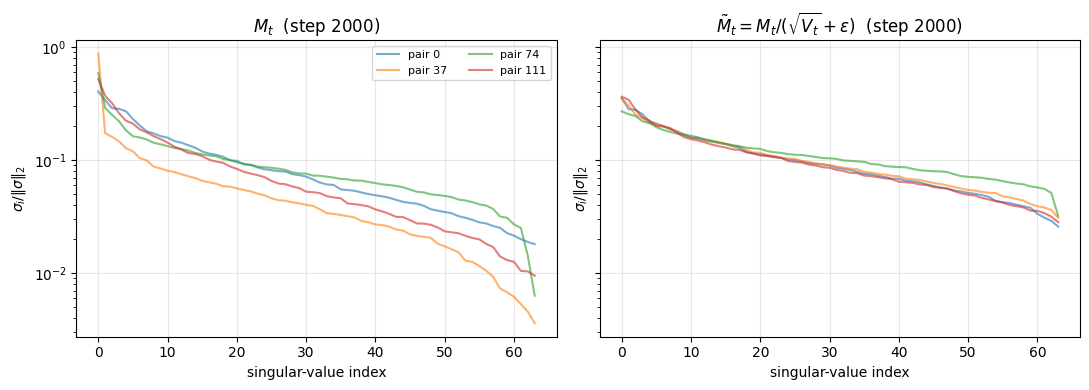

In [44]:
def normalized_sigmas(mat):
    s = torch.linalg.svdvals(mat.float()).numpy()
    return s / np.linalg.norm(s)  # sum(s²)=1 after this

def plot_spectra(step, pair_indices=None, n_pairs_to_plot=4, side='A'):
    snap = load_snapshot(step)
    n_pairs = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_pairs - 1, n_pairs_to_plot, dtype=int)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
    for pi in pair_indices:
        p = snap['pair_state'][int(pi)]
        s_M = normalized_sigmas(p[f'm_{side}'])
        s_Mt = normalized_sigmas(Mtilde(p, side, bias_correct=False))
        axes[0].plot(s_M,  alpha=0.6, label=f'pair {int(pi)}')
        axes[1].plot(s_Mt, alpha=0.6, label=f'pair {int(pi)}')
    axes[0].set_title(f'$M_t$  (step {step})')
    axes[1].set_title(f'$\\tilde M_t = M_t / (\\sqrt{{V_t}} + \\varepsilon)$  (step {step})')
    for ax in axes:
        ax.set_yscale('log')
        ax.set_xlabel('singular-value index')
        ax.set_ylabel('$\\sigma_i / \\|\\sigma\\|_2$')
        ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=8, ncol=2)
    fig.tight_layout()
    return fig

plot_spectra(2000, n_pairs_to_plot=4, side='A')
plt.show()

## Spectra of $S_A = A A^\top$ and $S_B = B^\top B$

Context for the whitening below: the chord-tight A-side update uses
$S_B^{-1/2}$ as a preconditioner, where $S_B = B^\top B \in \mathbb{R}^{r \times r}$
(symmetric for B-side, $S_A = A A^\top$). Whether whitening helps NS depends
on how poorly conditioned these Gram matrices are.

Eigenvalues of $S_A$, $S_B$ are also $\sigma_i(A)^2$, $\sigma_i(B)^2$ — so this
is equivalently the squared-singular-spectrum of the LoRA factors. Frobenius-
normalized to factor out per-layer scale; raw $\sigma_{\max}$ is reported in
the legend so the absolute scale isn't lost.

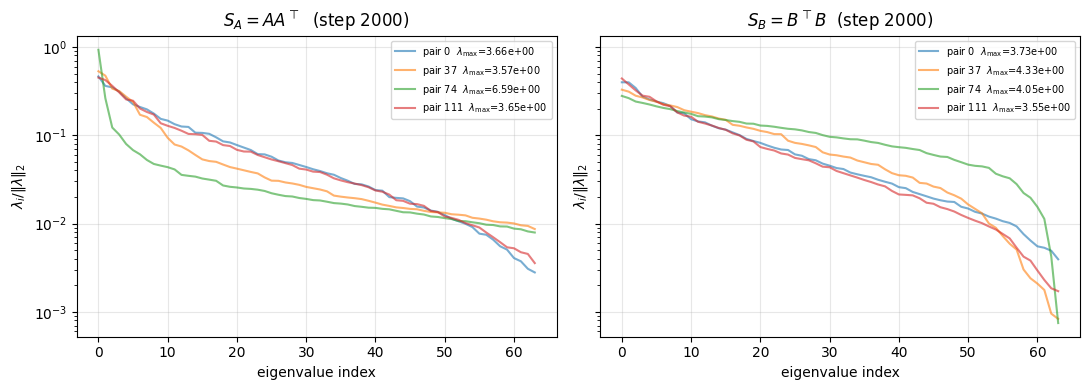

In [45]:
def plot_SA_SB_spectra(step, pair_indices=None, n_pairs_to_plot=4):
    snap = load_snapshot(step)
    n_pairs = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_pairs - 1, n_pairs_to_plot, dtype=int)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
    for pi in pair_indices:
        p = snap['pair_state'][int(pi)]
        A = p['A'].float(); B = p['B'].float()
        eA = torch.linalg.eigvalsh(A @ A.T).clamp_min(0).flip(0).numpy()
        eB = torch.linalg.eigvalsh(B.T @ B).clamp_min(0).flip(0).numpy()
        nA = eA / np.linalg.norm(eA); nB = eB / np.linalg.norm(eB)
        axes[0].plot(nA, alpha=0.6,
                     label=f'pair {int(pi)}  $\\lambda_{{\\max}}$={eA[0]:.2e}')
        axes[1].plot(nB, alpha=0.6,
                     label=f'pair {int(pi)}  $\\lambda_{{\\max}}$={eB[0]:.2e}')
    axes[0].set_title(f'$S_A = A A^\\top$  (step {step})')
    axes[1].set_title(f'$S_B = B^\\top B$  (step {step})')
    for ax in axes:
        ax.set_yscale('log')
        ax.set_xlabel('eigenvalue index')
        ax.set_ylabel(r'$\lambda_i / \|\lambda\|_2$')
        ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
    fig.tight_layout()
    return fig

plot_SA_SB_spectra(2000, n_pairs_to_plot=4)
plt.show()

## NS on $M_t$ vs $\tilde M_t$ (Adam-scaling effect through the NS lens)

The whitening cell above compared raw `u_A` vs whitened input $S_B^{-1/2} u_A$ —
both already post-Adam-scaling. This cell isolates the **Adam scaling step
itself**: run NS on the raw EMA momentum $M_t$ and on the Adam-scaled
$\tilde M_t = M_t / (\sqrt{V_t} + \varepsilon)$ and overlay the resulting
spectra.

Paper Fig. 1a/1b's claim is that $\tilde M_t$ has a much heavier spectrum than
$M_t$, which is what motivates the polar step. Here we ask: does that flatter
input spectrum actually make NS converge — or does NS hit the dead-zone on
both?

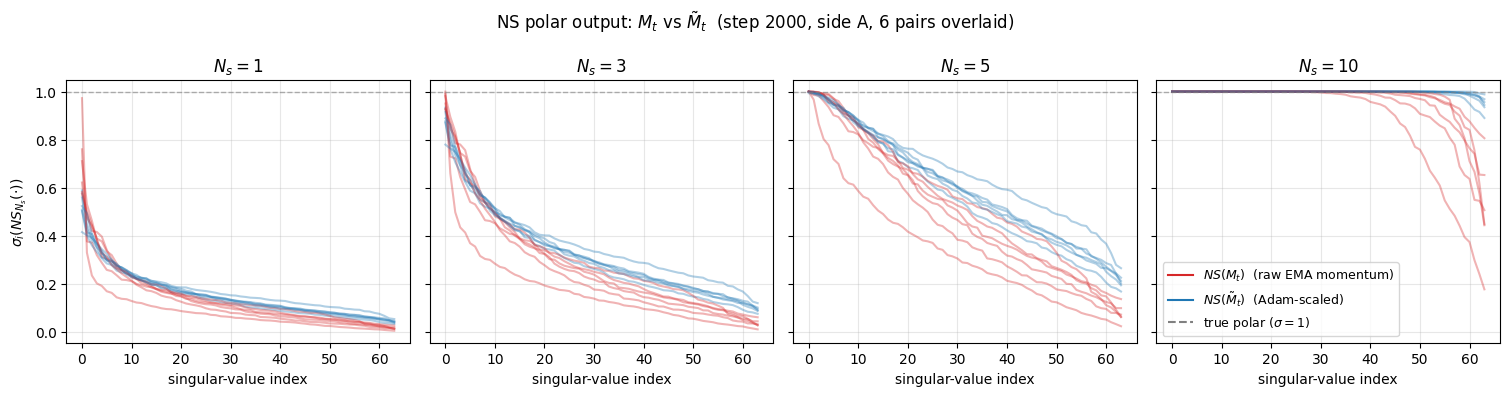

In [46]:
def newton_schulz_polar(M, K=5):
    X = M.float() / (M.float().norm() + 1e-12)
    for _ in range(K):
        X = 1.5 * X - 0.5 * (X @ X.transpose(-1, -2)) @ X
    return X

def plot_ns_M_vs_Mtilde(step, pair_indices=None, n_pairs=6, side='A',
                        Ks=(1, 3, 5, 10)):
    snap = load_snapshot(step)
    n_total = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)

    fig, axes = plt.subplots(1, len(Ks), figsize=(3.8 * len(Ks), 4),
                             sharey=True, sharex=True)
    for ax, K in zip(axes, Ks):
        for pi in pair_indices:
            p = snap['pair_state'][int(pi)]
            M  = p[f'm_{side}'].float()
            Mt = Mtilde(p, side, bias_correct=False)
            s_M  = torch.linalg.svdvals(newton_schulz_polar(M,  K)).numpy()
            s_Mt = torch.linalg.svdvals(newton_schulz_polar(Mt, K)).numpy()
            ax.plot(s_M,  color='C3', alpha=0.35)
            ax.plot(s_Mt, color='C0', alpha=0.35)
        ax.axhline(1.0, ls='--', color='gray', alpha=0.6, lw=1)
        ax.set_title(f'$N_s = {K}$')
        ax.set_xlabel('singular-value index')
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel(r'$\sigma_i(NS_{N_s}(\cdot))$')
    from matplotlib.lines import Line2D
    axes[-1].legend([Line2D([], [], color='C3'),
                     Line2D([], [], color='C0'),
                     Line2D([], [], color='gray', ls='--')],
                    [r'$NS(M_t)$  (raw EMA momentum)',
                     r'$NS(\tilde M_t)$  (Adam-scaled)',
                     r'true polar ($\sigma = 1$)'],
                    loc='lower left', fontsize=9)
    fig.suptitle(f'NS polar output: $M_t$ vs $\\tilde M_t$  '
                 f'(step {step}, side {side}, {n_pairs} pairs overlaid)')
    fig.tight_layout()
    return fig

plot_ns_M_vs_Mtilde(2000, n_pairs=6, side='A', Ks=(1, 3, 5, 10))
plt.show()

### Polar Express variant (Amsel et al. 2025, arXiv 2505.16932)

Same NS scaffolding (degree-5 odd polynomial $p_t(x) = a_t\,x + b_t\,x^3 + c_t\,x^5$), but coefficients are **optimized per-iteration** for $\sigma \in [10^{-3}, 1]$ (Implementation 1 in the paper). After iteration 8 the coefficients collapse to plain NS $(15/8, -10/8, 3/8)$. Input scaling: $X_0 = M / (\|M\|_F \cdot 1.01 + 10^{-7})$ — the $1.01$ safety factor is folded into the first 7 coefficient tuples ($a/1.01,\; b/1.01^3,\; c/1.01^5$).

Overlays below run NS and Polar Express on the *same* inputs at matched iteration counts so we can read off whether PE pulls singular values toward 1 faster than the $(1.5, -0.5)$ degree-3 NS used elsewhere in the notebook.

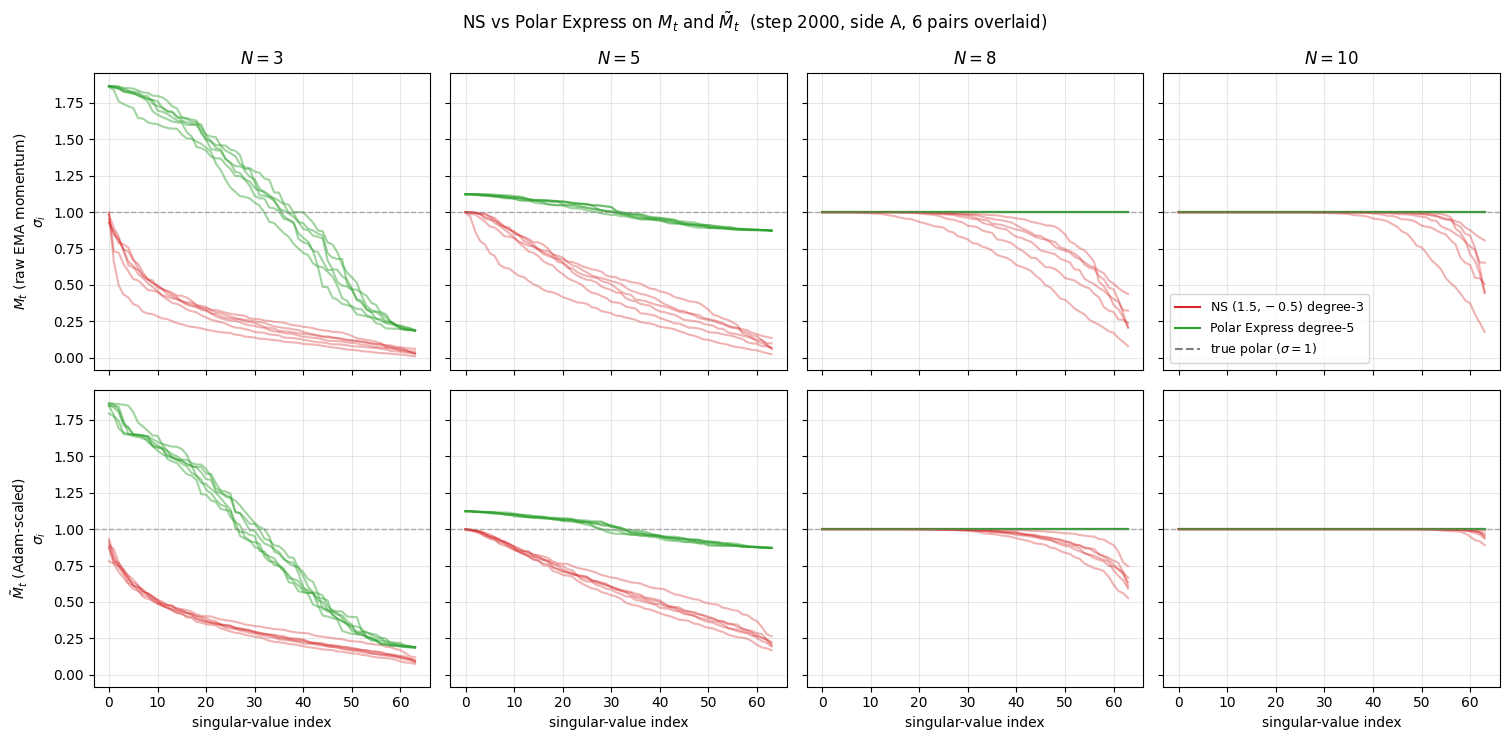

In [47]:
# Polar Express (PE) iteration — Amsel et al. 2025, Implementation 1.
# Uses the canonical implementation in lora_playground.optim so the
# visualization tracks production code; both _newton_schulz and
# _polar_express there use the small-side Gram form (Dao 2026, equiv).
from lora_playground.optim import _polar_express

def polar_express(M, K=5):
    return _polar_express(M, nsteps=K)

def plot_pe_vs_ns_M_vs_Mtilde(step, pair_indices=None, n_pairs=6, side='A',
                              Ks=(3, 5, 8, 10)):
    """Overlay NS and PE on M_t (raw EMA) and on Mtilde (Adam-scaled) at matched K."""
    snap = load_snapshot(step)
    n_total = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)

    fig, axes = plt.subplots(2, len(Ks), figsize=(3.8 * len(Ks), 7.5),
                             sharey=True, sharex=True)
    for row, (input_kind, label) in enumerate([
        ('M',  r'$M_t$ (raw EMA momentum)'),
        ('Mt', r'$\tilde M_t$ (Adam-scaled)'),
    ]):
        for ax, K in zip(axes[row], Ks):
            for pi in pair_indices:
                p = snap['pair_state'][int(pi)]
                X = (p[f'm_{side}'].float() if input_kind == 'M'
                     else Mtilde(p, side, bias_correct=False))
                s_ns = torch.linalg.svdvals(newton_schulz_polar(X, K)).numpy()
                s_pe = torch.linalg.svdvals(polar_express(X, K)).numpy()
                ax.plot(s_ns, color='C3', alpha=0.35)
                ax.plot(s_pe, color='C2', alpha=0.45)
            ax.axhline(1.0, ls='--', color='gray', alpha=0.6, lw=1)
            if row == 0:
                ax.set_title(f'$N = {K}$')
            ax.grid(True, alpha=0.3)
        axes[row, 0].set_ylabel(label + '\n' + r'$\sigma_i$')
    for ax in axes[-1]:
        ax.set_xlabel('singular-value index')
    from matplotlib.lines import Line2D
    axes[0, -1].legend([Line2D([], [], color='C3'),
                        Line2D([], [], color='C2'),
                        Line2D([], [], color='gray', ls='--')],
                       [r'NS $(1.5, -0.5)$ degree-3',
                        r'Polar Express degree-5',
                        r'true polar ($\sigma = 1$)'],
                       loc='lower left', fontsize=9)
    fig.suptitle(rf'NS vs Polar Express on $M_t$ and $\tilde M_t$  '
                 rf'(step {step}, side {side}, {n_pairs} pairs overlaid)')
    fig.tight_layout()
    return fig

plot_pe_vs_ns_M_vs_Mtilde(2000, n_pairs=6, side='A', Ks=(3, 5, 8, 10))
plt.show()


## Spectrum of $u_A$ vs whitened $S_B^{-1/2} u_A$ (chord-tight NS input)

Analog of the $M_t$ vs $\tilde M_t$ figure above, but on the actual §9
NS input: the bias-corrected Adam direction `u_A` and its whitened form
$S_B^{-1/2} u_A$ (with absolute damping $\delta_B = 10^{-6}$ matching the run's `--precond_delta 1e-6`). Frobenius-normalized
so only the shape of the spectrum matters.

Whitening should flatten the tail relative to raw $u_A$ — that's the
motivation for paying for $S_B^{-1/2}$. The whitened input feeds NS in
the next cell.

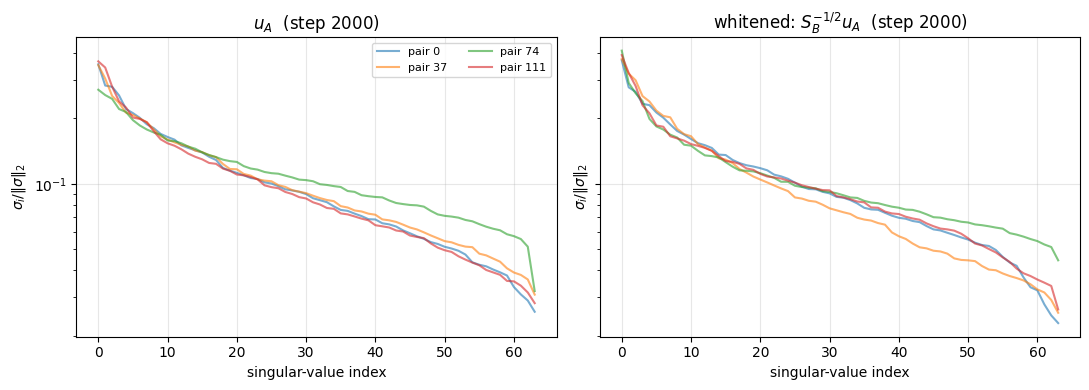

In [48]:
DELTA_ABS = 1e-6  # matches the run's --precond_delta 1e-6 (absolute, no --precond_delta_relative)

def spd_half_inv(S, delta_abs=DELTA_ABS):
    """Damped S^{-1/2}: S ← S + delta_abs·I, then eigendecompose."""
    evals = torch.linalg.eigvalsh(S)
    delta = delta_abs
    evals2, evecs = torch.linalg.eigh(S + delta * torch.eye(S.shape[0], dtype=S.dtype))
    return evecs @ torch.diag(evals2.clamp_min(1e-30).rsqrt()) @ evecs.T

def whitened_NS_input(pair, side='A'):
    """Whitened §9 NS input. Side A: X = S_B^{-1/2} @ u_A. Side B: X = u_B @ S_A^{-1/2}."""
    A = pair['A'].float(); B = pair['B'].float()
    u = pair[f'u_{side}'].float()
    if side == 'A':
        return spd_half_inv(B.T @ B) @ u
    else:
        return u @ spd_half_inv(A @ A.T)


def plot_spectra_u_vs_whitened(step, pair_indices=None, n_pairs_to_plot=4, side='A'):
    snap = load_snapshot(step)
    n_pairs = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_pairs - 1, n_pairs_to_plot, dtype=int)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
    for pi in pair_indices:
        p = snap['pair_state'][int(pi)]
        s_u = normalized_sigmas(p[f'u_{side}'])
        s_w = normalized_sigmas(whitened_NS_input(p, side=side))
        axes[0].plot(s_u, alpha=0.6, label=f'pair {int(pi)}')
        axes[1].plot(s_w, alpha=0.6, label=f'pair {int(pi)}')
    axes[0].set_title(f'$u_{side}$  (step {step})')
    sub = 'B' if side == 'A' else 'A'
    pre = f'S_{sub}^{{-1/2}} u_{side}' if side == 'A' else f'u_{side} S_{sub}^{{-1/2}}'
    axes[1].set_title(f'whitened: ${pre}$  (step {step})')
    for ax in axes:
        ax.set_yscale('log')
        ax.set_xlabel('singular-value index')
        ax.set_ylabel(r'$\sigma_i / \|\sigma\|_2$')
        ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=8, ncol=2)
    fig.tight_layout()
    return fig

plot_spectra_u_vs_whitened(2000, n_pairs_to_plot=4, side='A')
plt.show()

## Whitened vs unwhitened Newton–Schulz output spectrum

The §9 polar step in chord-tight is **`polar_NS(S_B^{-1/2} @ u_A)`** for the A-side
(symmetric for B). The whitening by $S_B^{-1/2}$ is supposed to precondition the
spectrum into a regime where NS converges quickly at the production $N_s = 5$.

This cell:
1. Computes the whitened input $X = S_B^{-1/2} u_A$ on each pair (with the
   absolute damping $\delta_B = 10^{-6}$ matching the run's `--precond_delta 1e-6`).
2. Runs NS at $N_s \in \{1, 3, 5, 10\}$ on both the **whitened** and the
   **unwhitened** (raw `u_A`) inputs, Frobenius-normalized at NS entry.
3. Overlays the resulting singular-value curves.

Two reads:
- **Whitening effect**: does $X$ have a tighter spectrum than $u_A$ before NS?
- **NS convergence sanity check**: does the whitened input reach $\sigma \to 1$
  by $N_s = 10$? If yes, $N_s = 5$ in production is a deliberate-imprecision
  choice (paper §3.2: muon tolerates $\varepsilon \approx 0.3$). If no, the
  whitened spectrum is still too heavy-tailed and NS-K is structurally short.

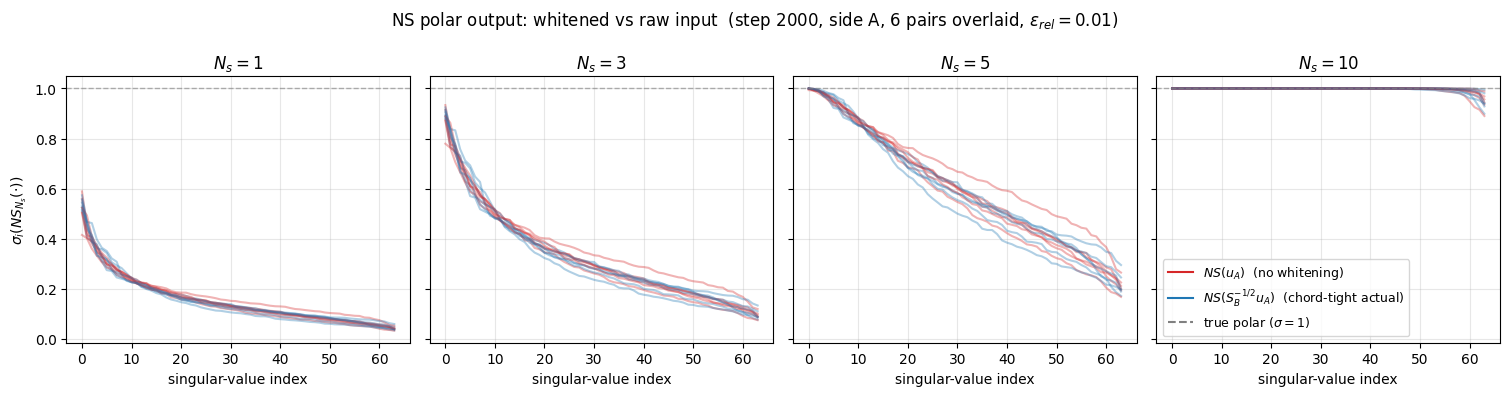

In [49]:
def plot_whitened_vs_naked(step, pair_indices=None, n_pairs=6, side='A',
                           Ks=(1, 3, 5, 10)):
    snap = load_snapshot(step)
    n_total = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)

    fig, axes = plt.subplots(1, len(Ks), figsize=(3.8 * len(Ks), 4),
                             sharey=True, sharex=True)
    for ax, K in zip(axes, Ks):
        for pi in pair_indices:
            p = snap['pair_state'][int(pi)]
            X_whiten = whitened_NS_input(p, side=side)
            X_naked  = p[f'u_{side}']
            s_w = torch.linalg.svdvals(newton_schulz_polar(X_whiten, K)).numpy()
            s_n = torch.linalg.svdvals(newton_schulz_polar(X_naked,  K)).numpy()
            ax.plot(s_n, color='C3', alpha=0.35)
            ax.plot(s_w, color='C0', alpha=0.35)
        ax.axhline(1.0, ls='--', color='gray', alpha=0.6, lw=1)
        ax.set_title(f'$N_s = {K}$')
        ax.set_xlabel('singular-value index')
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel(r'$\sigma_i(NS_{N_s}(\cdot))$')
    from matplotlib.lines import Line2D
    axes[-1].legend([Line2D([], [], color='C3'),
                     Line2D([], [], color='C0'),
                     Line2D([], [], color='gray', ls='--')],
                    [r'$NS(u_A)$  (no whitening)',
                     r'$NS(S_B^{-1/2} u_A)$  (chord-tight actual)',
                     r'true polar ($\sigma = 1$)'],
                    loc='lower left', fontsize=9)
    fig.suptitle(f'NS polar output: whitened vs raw input  '
                 f'(step {step}, side {side}, {n_pairs} pairs overlaid, '
                 f'$\\delta_{{abs}} = {DELTA_ABS}$)')
    fig.tight_layout()
    return fig

plot_whitened_vs_naked(2000, n_pairs=6, side='A', Ks=(1, 3, 5, 10))
plt.show()

### Polar Express on whitened vs raw $u_A$

Same NS-vs-PE overlay as above, but on the §9 production inputs: bias-corrected Adam direction $u_A$ and its whitened form $S_B^{-1/2} u_A$.

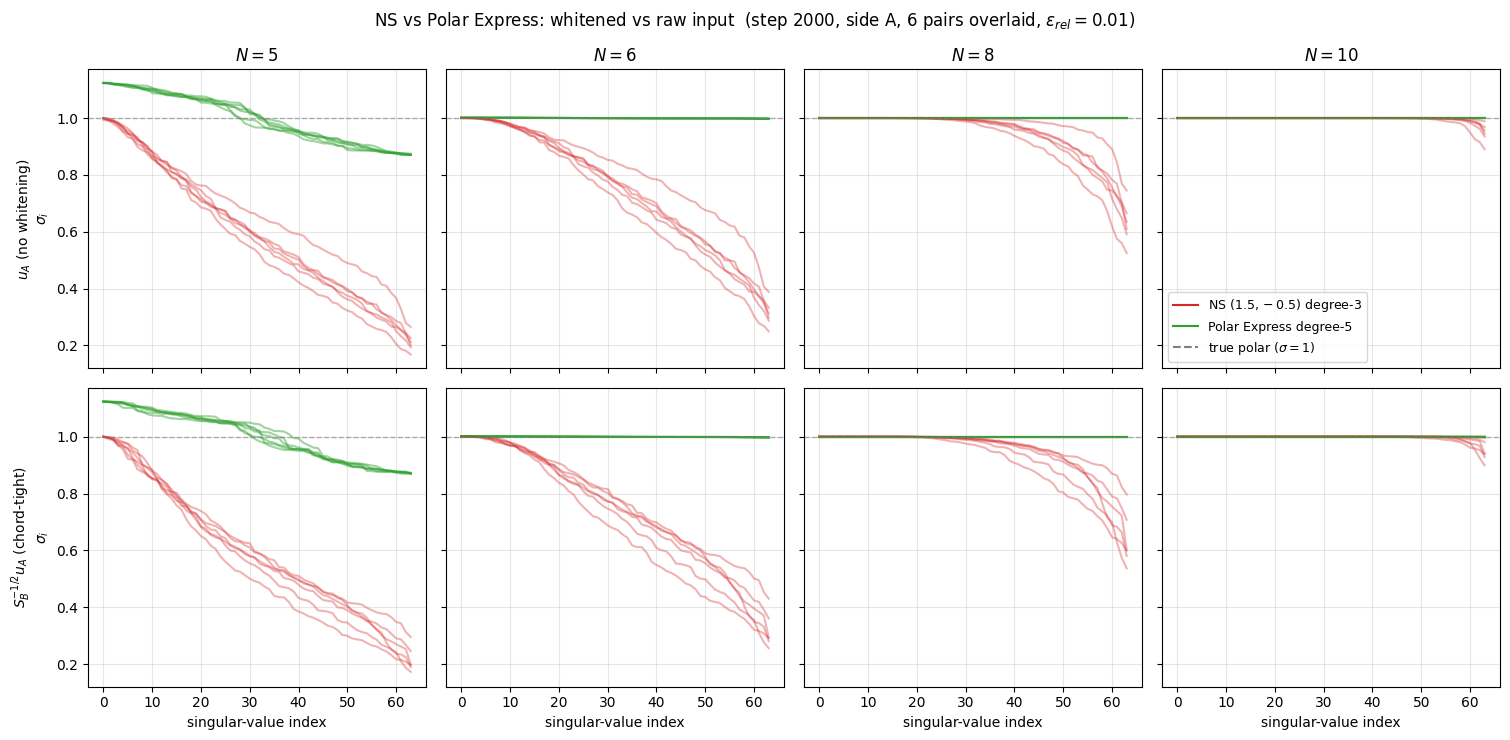

In [55]:
def plot_pe_vs_ns_whitened(step, pair_indices=None, n_pairs=6, side='A',
                           Ks=(3, 5, 8, 10)):
    snap = load_snapshot(step)
    n_total = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)

    fig, axes = plt.subplots(2, len(Ks), figsize=(3.8 * len(Ks), 7.5),
                             sharey=True, sharex=True)
    for row, (input_kind, label) in enumerate([
        ('naked',   r'$u_A$ (no whitening)'),
        ('whiten',  r'$S_B^{-1/2} u_A$ (chord-tight)'),
    ]):
        for ax, K in zip(axes[row], Ks):
            for pi in pair_indices:
                p = snap['pair_state'][int(pi)]
                X = (p[f'u_{side}'] if input_kind == 'naked'
                     else whitened_NS_input(p, side=side))
                s_ns = torch.linalg.svdvals(newton_schulz_polar(X, K)).numpy()
                s_pe = torch.linalg.svdvals(polar_express(X, K)).numpy()
                ax.plot(s_ns, color='C3', alpha=0.35)
                ax.plot(s_pe, color='C2', alpha=0.45)
            ax.axhline(1.0, ls='--', color='gray', alpha=0.6, lw=1)
            if row == 0:
                ax.set_title(f'$N = {K}$')
            ax.grid(True, alpha=0.3)
        axes[row, 0].set_ylabel(label + '\n' + r'$\sigma_i$')
    for ax in axes[-1]:
        ax.set_xlabel('singular-value index')
    from matplotlib.lines import Line2D
    axes[0, -1].legend([Line2D([], [], color='C3'),
                        Line2D([], [], color='C2'),
                        Line2D([], [], color='gray', ls='--')],
                       [r'NS $(1.5, -0.5)$ degree-3',
                        r'Polar Express degree-5',
                        r'true polar ($\sigma = 1$)'],
                       loc='lower left', fontsize=9)
    fig.suptitle(f'NS vs Polar Express: whitened vs raw input  '
                 f'(step {step}, side {side}, {n_pairs} pairs overlaid, '
                 rf'$\delta_{{abs}} = {DELTA_ABS}$)')
    fig.tight_layout()
    return fig

plot_pe_vs_ns_whitened(2000, n_pairs=6, side='A', Ks=(5, 6, 8, 10))
plt.show()


## How active is the bilinear term? ρ vs η/s over training

Tight-chord radius (§8 Prop 3, eq 6): $\rho = \tfrac{1}{2}(-s + \sqrt{s^2 + 4\eta})$ with $s = \sigma_{\max}(A) + \sigma_{\max}(B)$.

Two regimes:
- **Linear** ($s^2 \gg \eta$): $\rho \approx \eta/s$, second-order $\Delta B \Delta A$ term negligible.
- **Square-root** ($s^2 \ll \eta$): $\rho \approx \sqrt{\eta} - s/2$, bilinear term dominates.

Diagnostic: $\rho / (\eta/s)$ — close to 1 means deep linear regime. Plot per-pair distribution across snapshot steps.

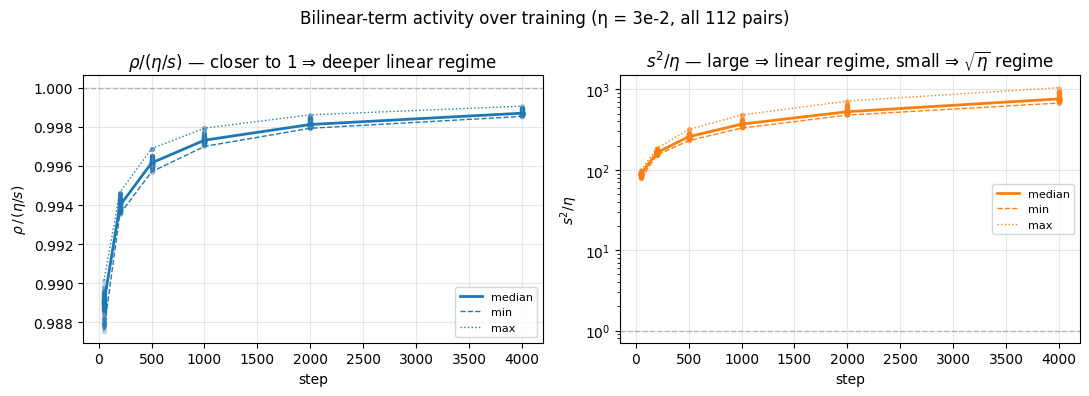

step | median ρ/(η/s) |   min   |   max   | median s²/η
   50 |    0.98899    | 0.98758 | 0.99014 |      88.8
  200 |    0.99396    | 0.99353 | 0.99464 |     163.7
  500 |    0.99615    | 0.99570 | 0.99688 |     257.9
 1000 |    0.99731    | 0.99700 | 0.99793 |     370.3
 2000 |    0.99812    | 0.99792 | 0.99861 |     528.9
 4000 |    0.99869    | 0.99853 | 0.99905 |     763.4


In [51]:
def collect_rho_over_time(eta=3e-2):
    rows = []
    for step in STEPS:
        if step == 0:
            continue  # B initialized to zero — s ≈ 0, undefined regime
        snap = load_snapshot(step)
        DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
        for pi, p in snap['pair_state'].items():
            A = p['A'].float().to(DEV); B = p['B'].float().to(DEV)
            sA_max = torch.linalg.svdvals(A)[0].item()
            sB_max = torch.linalg.svdvals(B)[0].item()
            s = sA_max + sB_max
            rho = 0.5 * (-s + (s*s + 4*eta)**0.5)
            rows.append(dict(step=step, pi=pi, s=s, rho=rho,
                             rho_over_rholin=rho * s / eta,
                             s2_over_eta=(s*s)/eta))
    return rows

rows = collect_rho_over_time(eta=3e-2)
steps_arr = sorted({r['step'] for r in rows})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for step in steps_arr:
    vals_ratio = [r['rho_over_rholin'] for r in rows if r['step'] == step]
    vals_s2eta = [r['s2_over_eta']     for r in rows if r['step'] == step]
    axes[0].scatter([step]*len(vals_ratio), vals_ratio, alpha=0.25, s=8, color='C0')
    axes[1].scatter([step]*len(vals_s2eta), vals_s2eta, alpha=0.25, s=8, color='C1')

for ax_i, key, color in [(0, 'rho_over_rholin', 'C0'), (1, 's2_over_eta', 'C1')]:
    med, mn, mx = [], [], []
    for step in steps_arr:
        vs = np.array([r[key] for r in rows if r['step'] == step])
        med.append(np.median(vs)); mn.append(vs.min()); mx.append(vs.max())
    axes[ax_i].plot(steps_arr, med, color=color, lw=2, label='median')
    axes[ax_i].plot(steps_arr, mn,  color=color, lw=1, ls='--', label='min')
    axes[ax_i].plot(steps_arr, mx,  color=color, lw=1, ls=':',  label='max')

axes[0].axhline(1.0, color='gray', ls='--', alpha=0.5, lw=1)
axes[0].set_ylabel(r'$\rho \,/\, (\eta / s)$')
axes[0].set_xlabel('step')
axes[0].set_title(r'$\rho / (\eta/s)$ — closer to 1 ⇒ deeper linear regime')
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

axes[1].set_yscale('log')
axes[1].axhline(1.0, color='gray', ls='--', alpha=0.5, lw=1)
axes[1].set_ylabel(r'$s^2 / \eta$')
axes[1].set_xlabel('step')
axes[1].set_title(r'$s^2 / \eta$ — large ⇒ linear regime, small ⇒ $\sqrt{\eta}$ regime')
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)

fig.suptitle(f'Bilinear-term activity over training (η = 3e-2, all 112 pairs)')
fig.tight_layout()
plt.show()

print('step | median ρ/(η/s) |   min   |   max   | median s²/η')
for step in steps_arr:
    vs = [r['rho_over_rholin'] for r in rows if r['step'] == step]
    s2 = [r['s2_over_eta']     for r in rows if r['step'] == step]
    print(f'{step:5d} |    {np.median(vs):.5f}    | {min(vs):.5f} | {max(vs):.5f} |   {np.median(s2):7.1f}')


## Saturating-hypothesis (H) activity over training (Algorithm 1 vs Algorithm 2)

(H) (§7 eq H): $\tau_A \le \eta\,\sigma_{\min}(c_A^{(n)})$, equivalently every singular value of $\eta\,c_A^{(n)}$ is at least $\tau_A$. When (H) holds, clip = polar on the whitened input and Algorithm 2 is exact (§9). When (H) fails, polar lifts small singular values that clip would have left alone.

At BJ iterate $n=1$, $\tilde u_A = u_A$ (the snapshot already has $u_A$), so $c_A^{(1)} = S_B^{-1/2}\,u_A$ is fully recoverable from the snapshot.

Diagnostics per pair per step:
- `min_ratio` = $\sigma_{\min}(\eta\,c_A^{(1)}) / \tau_A$ — (H) holds iff this is ≥ 1.
- `frac_below` = fraction of singular values of $\eta\,c_A^{(1)}$ that fall below $\tau_A$.
- `clip_polar_relF` = $\|\Delta A^{\text{clip}} - \Delta A^{\text{polar}}\|_F / \|\Delta A^{\text{polar}}\|_F$ at iterate 1 — direct measure of how much the saturating substitution costs the update.

A-side only (B-side is symmetric).

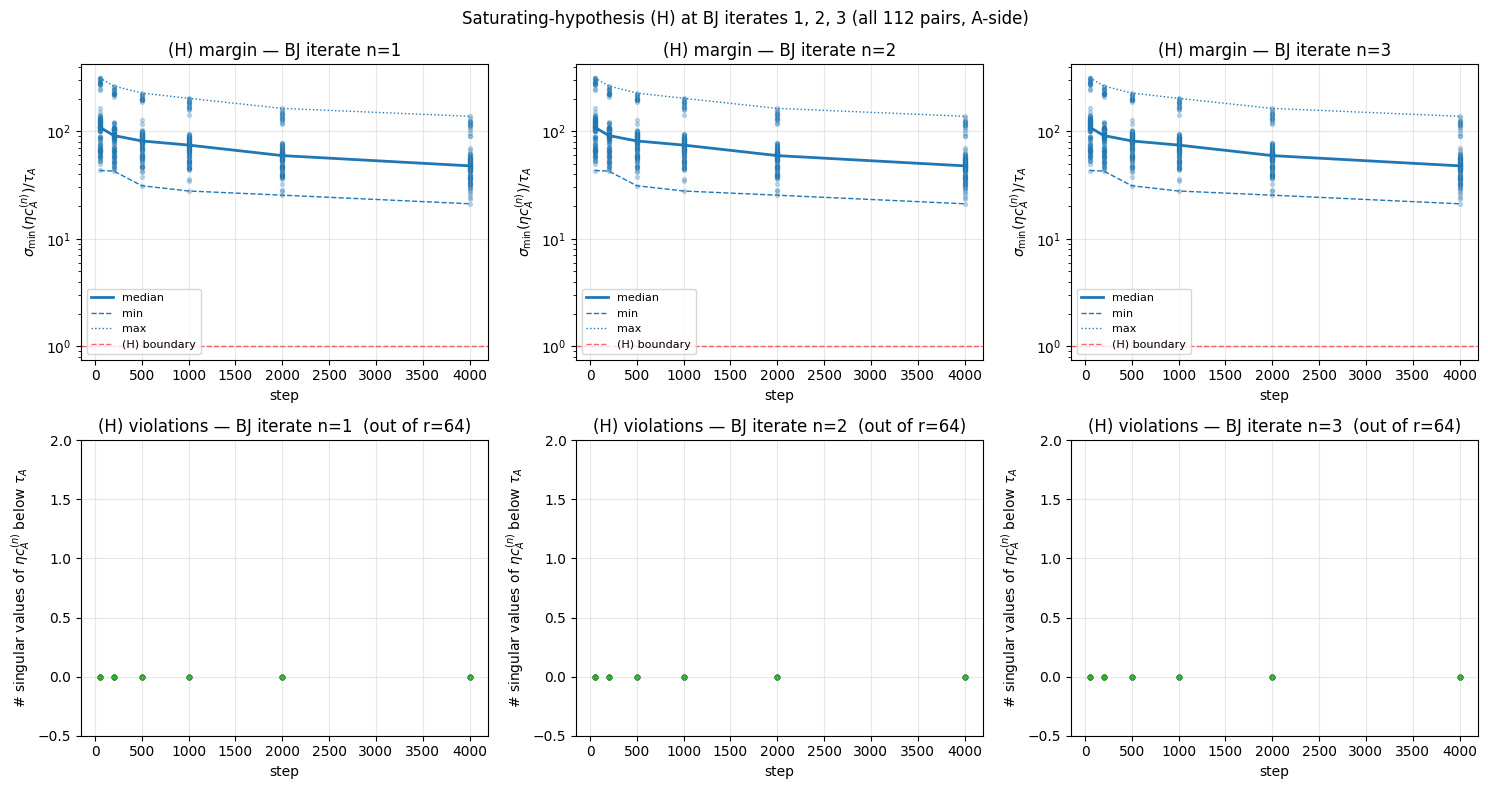

step | iter | med margin | min margin | max margin | median n_below | max n_below
   50 |    1 |     109.05 |      43.15 |     314.39 |              0 |           0
   50 |    2 |     109.01 |      43.12 |     314.35 |              0 |           0
   50 |    3 |     109.01 |      43.12 |     314.35 |              0 |           0
  200 |    1 |      91.24 |      42.62 |     263.43 |              0 |           0
  200 |    2 |      91.22 |      42.60 |     263.41 |              0 |           0
  200 |    3 |      91.22 |      42.60 |     263.41 |              0 |           0
  500 |    1 |      81.24 |      31.14 |     226.65 |              0 |           0
  500 |    2 |      81.22 |      31.13 |     226.63 |              0 |           0
  500 |    3 |      81.22 |      31.13 |     226.63 |              0 |           0
 1000 |    1 |      74.37 |      27.82 |     202.40 |              0 |           0
 1000 |    2 |      74.35 |      27.80 |     202.37 |              0 |           0
 1000

In [52]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'

def saturating_diag(step, eta=3e-2, delta_abs=1e-6, n_iters=3, ns_iters=5):
    """(H) check at BJ iterates 1..n_iters.  Runs the inner loop, computes
    min ratio sigma_i(eta*c_A^{(n)}) / tau_A at each iterate."""
    snap = load_snapshot(step)
    rows = []
    for pi, p in snap['pair_state'].items():
        A = p['A'].float().to(DEV); B = p['B'].float().to(DEV)
        u_A = p['u_A'].float().to(DEV); u_B = p['u_B'].float().to(DEV)
        r = A.shape[0]
        I_r = torch.eye(r, dtype=A.dtype, device=DEV)
        S_B = B.T @ B
        eB = torch.linalg.eigvalsh(S_B).clamp_min(0)
        delta_B = delta_abs
        e2B, UB = torch.linalg.eigh(S_B + delta_B * I_r)
        W_B = UB @ torch.diag(e2B.clamp_min(1e-30).rsqrt()) @ UB.T
        sB_max = eB.max().sqrt().item(); sB_min = eB.min().sqrt().item()
        S_A = A @ A.T
        eA = torch.linalg.eigvalsh(S_A).clamp_min(0)
        delta_A = delta_abs
        e2A, UA = torch.linalg.eigh(S_A + delta_A * I_r)
        W_A = UA @ torch.diag(e2A.clamp_min(1e-30).rsqrt()) @ UA.T
        sA_max = eA.max().sqrt().item(); sA_min = eA.min().sqrt().item()
        s = sA_max + sB_max
        rho = eta / s   # linear form
        tau_A = rho * (sB_min**2 + delta_B)**0.5
        tau_B = rho * (sA_min**2 + delta_A)**0.5

        dA = torch.zeros_like(A); dB = torch.zeros_like(B)
        margins_A = []; margins_B = []; n_below_A_list = []
        for n in range(n_iters):
            u_A_tilde = u_A + (1.0/eta) * (B.T @ dB @ A)
            u_B_tilde = u_B + (1.0/eta) * (B @ dA @ A.T)
            c_A = W_B @ u_A_tilde
            c_B = u_B_tilde @ W_A
            # All r singular values of eta*c_A via Gram
            sig_eta_cA = (eta*eta * torch.linalg.eigvalsh(c_A @ c_A.T).clamp_min(0)).sqrt()
            sig_eta_cB = (eta*eta * torch.linalg.eigvalsh(c_B.T @ c_B).clamp_min(0)).sqrt()
            margins_A.append((sig_eta_cA.min() / tau_A).item())
            margins_B.append((sig_eta_cB.min() / tau_B).item())
            n_below_A_list.append((sig_eta_cA < tau_A).sum().item())
            # Update for next iter
            D_A = W_B @ newton_schulz_polar(c_A, ns_iters)
            D_B = newton_schulz_polar(c_B, ns_iters) @ W_A
            D_A_op = torch.linalg.eigvalsh(D_A @ D_A.T).clamp_min(0).max().sqrt().item()
            D_B_op = torch.linalg.eigvalsh(D_B.T @ D_B).clamp_min(0).max().sqrt().item()
            dA = -rho * D_A / D_A_op
            dB = -rho * D_B / D_B_op

        # Iter-1 only: clip-vs-polar Frob distance (for legacy)
        c_A_1 = W_B @ u_A
        Uc, Sc, Vct = torch.linalg.svd(-eta * c_A_1, full_matrices=False)
        clip_inner = Uc @ torch.diag(Sc.clamp_max(tau_A)) @ Vct
        dA_clip = W_B @ clip_inner
        Up, Sp, Vpt = torch.linalg.svd(c_A_1, full_matrices=False)
        D_A_1 = W_B @ (Up @ Vpt)
        D_A_op = torch.linalg.eigvalsh(D_A_1 @ D_A_1.T).clamp_min(0).max().sqrt().item()
        dA_polar = -rho * D_A_1 / D_A_op
        rel_F = (dA_clip - dA_polar).norm().item() / dA_polar.norm().item()
        rows.append(dict(step=step, pi=pi,
                         margin_A_iter1=margins_A[0], margin_A_iter2=margins_A[1] if n_iters>1 else None,
                         margin_A_iter3=margins_A[2] if n_iters>2 else None,
                         margin_B_iter1=margins_B[0], margin_B_iter2=margins_B[1] if n_iters>1 else None,
                         margin_B_iter3=margins_B[2] if n_iters>2 else None,
                         n_below_A_iter1=n_below_A_list[0],
                         n_below_A_iter2=n_below_A_list[1] if n_iters>1 else None,
                         n_below_A_iter3=n_below_A_list[2] if n_iters>2 else None,
                         clip_polar_relF=rel_F))
    return rows

H_rows = []
for step in STEPS:
    if step == 0: continue
    H_rows.extend(saturating_diag(step, n_iters=3))

steps_arr = sorted({r['step'] for r in H_rows})

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Top row: per-iterate (H) margin (min ratio) across pairs
for col, iter_n in enumerate([1, 2, 3]):
    key = f'margin_A_iter{iter_n}'
    for step in steps_arr:
        mr = [r[key] for r in H_rows if r['step'] == step]
        axes[0, col].scatter([step]*len(mr), mr, alpha=0.25, s=8, color='C0')
    med = []; mn = []; mx = []
    for step in steps_arr:
        vs = np.array([r[key] for r in H_rows if r['step'] == step])
        med.append(np.median(vs)); mn.append(vs.min()); mx.append(vs.max())
    axes[0, col].plot(steps_arr, med, color='C0', lw=2, label='median')
    axes[0, col].plot(steps_arr, mn,  color='C0', lw=1, ls='--', label='min')
    axes[0, col].plot(steps_arr, mx,  color='C0', lw=1, ls=':',  label='max')
    axes[0, col].axhline(1.0, color='red', ls='--', alpha=0.6, lw=1, label='(H) boundary')
    axes[0, col].set_yscale('log')
    axes[0, col].set_ylabel(r'$\sigma_{\min}(\eta c_A^{(n)}) / \tau_A$')
    axes[0, col].set_xlabel('step')
    axes[0, col].set_title(f'(H) margin — BJ iterate n={iter_n}')
    axes[0, col].grid(True, alpha=0.3); axes[0, col].legend(fontsize=8)

# Bottom row: n_below count at each iterate (should be 0 always)
for col, iter_n in enumerate([1, 2, 3]):
    key = f'n_below_A_iter{iter_n}'
    for step in steps_arr:
        nb_ = [r[key] for r in H_rows if r['step'] == step]
        axes[1, col].scatter([step]*len(nb_), nb_, alpha=0.25, s=8, color='C2')
    axes[1, col].set_ylim(-0.5, max(2, max(r[key] for r in H_rows) + 1))
    axes[1, col].set_ylabel(r'# singular values of $\eta c_A^{(n)}$ below $\tau_A$')
    axes[1, col].set_xlabel('step')
    axes[1, col].set_title(f'(H) violations — BJ iterate n={iter_n}  (out of r={H_rows[0].get("n", 64) if H_rows else 64})')
    axes[1, col].grid(True, alpha=0.3)

fig.suptitle('Saturating-hypothesis (H) at BJ iterates 1, 2, 3 (all 112 pairs, A-side)')
fig.tight_layout()
plt.show()

print('step | iter | med margin | min margin | max margin | median n_below | max n_below')
for step in steps_arr:
    for n in [1,2,3]:
        mr = np.array([r[f'margin_A_iter{n}'] for r in H_rows if r['step'] == step])
        nb_ = np.array([r[f'n_below_A_iter{n}'] for r in H_rows if r['step'] == step])
        print(f'{step:5d} | {n:>4d} | {np.median(mr):>10.2f} | {mr.min():>10.2f} | {mr.max():>10.2f} | {int(np.median(nb_)):>14d} | {int(nb_.max()):>11d}')


### Dense-cadence trajectory from the logged `optim_step` diagnostics

Snapshots are at 7 steps. The training log records per-pair-aggregated $\sigma_{\max}(AA^\top), \sigma_{\max}(B^\top B)$ as min/median/max across pairs every 80 steps (50 datapoints over 4000 steps). Use those to plot $\rho/(\eta/s)$ at full cadence.

Caveat: the median curve uses $s_{\text{med}} = \sqrt{S_{A,\max}^{\text{med}}} + \sqrt{S_{B,\max}^{\text{med}}}$ — the median-of-A plus median-of-B, not the median across pairs of the pairwise sum. The min/max envelope is also a loose bound for the same reason. For a properly per-pair view, the snapshot-based cell above is exact; this cell is a denser overlay.

parsed 50 optim_step events


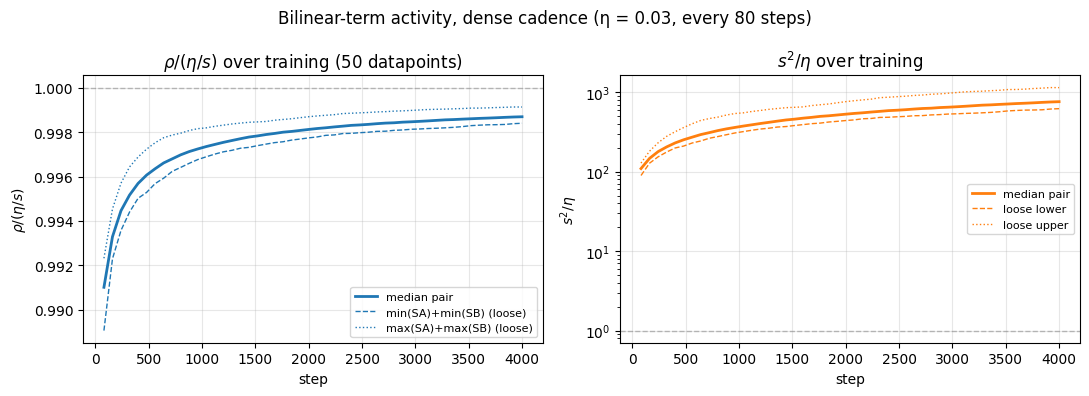


step | median ρ/(η/s) | loose min | loose max
   80 |    0.99102    |  0.98907  |  0.99232
  880 |    0.99712    |  0.99659  |  0.99807
 1680 |    0.99794    |  0.99752  |  0.99853
 2480 |    0.99832    |  0.99797  |  0.99886
 3280 |    0.99855    |  0.99819  |  0.99903
 4000 |    0.99869    |  0.99839  |  0.99913


In [53]:
LOG_PATH = '/mnt/home/nghosh/lora/logs/chord_tight_r64_k3_snapshot_blackwell/run_info/logs/log_0.out'

def parse_optim_steps(path):
    rows = []
    with open(path) as f:
        for line in f:
            try:
                d = json.loads(line)
            except json.JSONDecodeError:
                continue
            if d.get('event') == 'optim_step':
                rows.append(d)
    return rows

opt_rows = parse_optim_steps(LOG_PATH)
print(f'parsed {len(opt_rows)} optim_step events')

ETA = 3e-2
steps_arr = [r['step'] for r in opt_rows]

def rho_over_etas(sA2, sB2):
    s = np.sqrt(sA2) + np.sqrt(sB2)
    rho = 0.5 * (-s + np.sqrt(s*s + 4*ETA))
    return rho * s / ETA, (s*s) / ETA, s

ratio_med, s2_med, s_med = zip(*[rho_over_etas(r['SA_max_median'], r['SB_max_median']) for r in opt_rows])
ratio_min, s2_min, _     = zip(*[rho_over_etas(r['SA_max_min'],    r['SB_max_min'])    for r in opt_rows])
ratio_max, s2_max, _     = zip(*[rho_over_etas(r['SA_max_max'],    r['SB_max_max'])    for r in opt_rows])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(steps_arr, ratio_med, color='C0', lw=2, label='median pair')
axes[0].plot(steps_arr, ratio_min, color='C0', lw=1, ls='--', label='min(SA)+min(SB) (loose)')
axes[0].plot(steps_arr, ratio_max, color='C0', lw=1, ls=':', label='max(SA)+max(SB) (loose)')
axes[0].axhline(1.0, color='gray', ls='--', alpha=0.5, lw=1)
axes[0].set_xlabel('step'); axes[0].set_ylabel(r'$\rho / (\eta/s)$')
axes[0].set_title(r'$\rho / (\eta/s)$ over training (50 datapoints)')
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

axes[1].plot(steps_arr, s2_med, color='C1', lw=2, label='median pair')
axes[1].plot(steps_arr, s2_min, color='C1', lw=1, ls='--', label='loose lower')
axes[1].plot(steps_arr, s2_max, color='C1', lw=1, ls=':',  label='loose upper')
axes[1].set_yscale('log')
axes[1].axhline(1.0, color='gray', ls='--', alpha=0.5, lw=1)
axes[1].set_xlabel('step'); axes[1].set_ylabel(r'$s^2 / \eta$')
axes[1].set_title(r'$s^2/\eta$ over training')
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)

fig.suptitle(f'Bilinear-term activity, dense cadence (η = {ETA}, every 80 steps)')
fig.tight_layout()
plt.show()

print()
print(f'step | median ρ/(η/s) | loose min | loose max')
for i in [0, 10, 20, 30, 40, 49]:
    if i < len(steps_arr):
        print(f'{steps_arr[i]:5d} |    {ratio_med[i]:.5f}    |  {ratio_min[i]:.5f}  |  {ratio_max[i]:.5f}')


## BJ inner-loop convergence (chord-tight)

Algorithm 2 (§9 of `algorithm_tight_chord.md`) runs $k$ block-Jacobi sweeps to refine the cross-coupling correction. Production uses $k=3$. Simulate the BJ loop from a snapshot's $(A, B, u_A, u_B)$ — initial $\mathrm dA = \mathrm dB = 0$, then sweep with the cross-coupling correction, whiten + NS-polar + unwhiten, normalize-and-scale-by-$\rho_{tight} = \eta/s$.

Diagnostics:
- **distance to converged**: $\|\mathrm dA^{(n)} - \mathrm dA^{(K)}\|_F / \|\mathrm dA^{(K)}\|_F$ at large $K$
- **consecutive-iterate change**: $\|\mathrm dA^{(n)} - \mathrm dA^{(n-1)}\|_F / \|\mathrm dA^{(n)}\|_F$ — how much each sweep is still moving

These say the same thing from complementary angles: dA reaches the converged value in 2 iterates; iter 1 was 4.5e-4 away (relative), iter 2 ≈ converged to ~1e-6. The big jump is iter 1 → iter 2.

**Note**: a Φ excess panel was previously included but removed — the iter-to-iter Φ change at convergence (~1e-4 absolute on Φ of magnitude ~3) is below float32 precision (production uses float32 optimizer math). Distance-to-converged is the more reliable convergence indicator.

The chord-tight vs chord-direction comparison is in the next cell.

In [54]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'

def simulate_bcd(p, eta=3e-2, delta_abs=1e-6, K=10, ns_iters=10):
    """Block-Jacobi inner-loop simulation under chord-tight magnitude (rho = eta/s).
    All op-norms via Gram-matrix tricks on r x r or 2r x 2r matrices —
    no svdvals on (r, d_in) or (d_out, d_in)."""
    A = p['A'].float().to(DEV); B = p['B'].float().to(DEV)
    u_A = p['u_A'].float().to(DEV); u_B = p['u_B'].float().to(DEV)
    r = A.shape[0]; I_r = torch.eye(r, dtype=A.dtype, device=A.device)
    S_B = B.T @ B
    eB_raw = torch.linalg.eigvalsh(S_B).clamp_min(0)
    delta_B = delta_abs
    e2B, UB = torch.linalg.eigh(S_B + delta_B*I_r)
    W_B = UB @ torch.diag(e2B.clamp_min(1e-30).rsqrt()) @ UB.T
    sB_max = eB_raw.max().sqrt().item()
    S_A = A @ A.T
    eA_raw = torch.linalg.eigvalsh(S_A).clamp_min(0)
    delta_A = delta_abs
    e2A, UA = torch.linalg.eigh(S_A + delta_A*I_r)
    W_A = UA @ torch.diag(e2A.clamp_min(1e-30).rsqrt()) @ UA.T
    sA_max = eA_raw.max().sqrt().item()
    rho = eta / (sA_max + sB_max)

    dA = torch.zeros_like(A); dB = torch.zeros_like(B)
    traj_dA, traj_dB, traj_J, traj_phi = [], [], [], []
    for n in range(K):
        u_A_tilde = u_A + (1.0/eta)*(B.T @ dB @ A)
        u_B_tilde = u_B + (1.0/eta)*(B @ dA @ A.T)
        D_A = W_B @ newton_schulz_polar(W_B @ u_A_tilde, ns_iters)
        D_B = newton_schulz_polar(u_B_tilde @ W_A, ns_iters) @ W_A
        D_A_op = torch.linalg.eigvalsh(D_A @ D_A.T).clamp_min(0).max().sqrt().item()
        D_B_op = torch.linalg.eigvalsh(D_B.T @ D_B).clamp_min(0).max().sqrt().item()
        dA = -rho * D_A / D_A_op
        dB = -rho * D_B / D_B_op
        # ||J||_2 via rank-2r Gram trick
        U_2 = torch.cat([B, dB], dim=1); V_2 = torch.cat([dA, A], dim=0)
        J_op = torch.linalg.eigvals((U_2.T @ U_2) @ (V_2 @ V_2.T)).real.clamp_min(0).max().sqrt().item()
        J = B @ dA + dB @ A
        phi = (u_A * dA).sum().item() + (u_B * dB).sum().item() + (1.0/(2*eta)) * J.pow(2).sum().item()
        traj_dA.append(dA.detach().cpu()); traj_dB.append(dB.detach().cpu())
        traj_J.append(J_op); traj_phi.append(phi)
    return traj_dA, traj_dB, traj_J, traj_phi

def collect_bcd_convergence(step, K=10, n_pairs=None):
    snap = load_snapshot(step)
    results = []
    items = list(snap['pair_state'].items())
    if n_pairs is not None:
        items = items[:n_pairs]
    for pi, p in items:
        traj_dA, traj_dB, traj_J, traj_phi = simulate_bcd(p, K=K)
        final_dA, final_dB = traj_dA[-1], traj_dB[-1]
        rel_dA = [(traj_dA[n] - final_dA).norm().item() / (final_dA.norm().item() + 1e-30) for n in range(K)]
        rel_dB = [(traj_dB[n] - final_dB).norm().item() / (final_dB.norm().item() + 1e-30) for n in range(K)]
        rel_consec_A = [(traj_dA[n] - traj_dA[n-1]).norm().item() / (traj_dA[n].norm().item() + 1e-30) for n in range(1, K)]
        rel_consec_B = [(traj_dB[n] - traj_dB[n-1]).norm().item() / (traj_dB[n].norm().item() + 1e-30) for n in range(1, K)]
        results.append(dict(pi=pi, rel_dA=rel_dA, rel_dB=rel_dB,
                            rel_consec_A=rel_consec_A, rel_consec_B=rel_consec_B,
                            traj_J=traj_J, traj_phi=traj_phi))
    return results

ETA = 3e-2; K = 10
res = collect_bcd_convergence(2000, K=K)
print(f'simulated BJ K={K} on {len(res)} pairs at step 2000')

iters = np.arange(1, K+1)
iters_c = np.arange(2, K+1)

def panel_log(ax, key, color, title, ylabel, x=iters):
    arr = np.array([r[key] for r in res])
    for row in arr:
        ax.plot(x, row, color=color, alpha=0.2, lw=0.8)
    ax.plot(x, np.median(arr, axis=0), color=color, lw=2, label='median')
    ax.plot(x, arr.max(axis=0), color=color, lw=1, ls=':',  label='max')
    ax.plot(x, arr.min(axis=0), color=color, lw=1, ls='--', label='min')
    ax.axvline(3, color='red', ls='--', alpha=0.6, lw=1, label='production k=3')
    ax.set_yscale('log'); ax.set_xlabel('BJ iterate n'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

panel_log(axes[0,0], 'rel_dA', 'C0', 'distance to converged dA',
          r'$\|dA^{(n)} - dA^{(K)}\|_F / \|dA^{(K)}\|_F$')
panel_log(axes[0,1], 'rel_consec_A', 'C2', 'consecutive-iterate change (dA)',
          r'$\|dA^{(n)} - dA^{(n-1)}\|_F / \|dA^{(n)}\|_F$', x=iters_c)

panel_log(axes[1,0], 'rel_dB', 'C1', 'distance to converged dB',
          r'$\|dB^{(n)} - dB^{(K)}\|_F / \|dB^{(K)}\|_F$')
panel_log(axes[1,1], 'rel_consec_B', 'C3', 'consecutive-iterate change (dB)',
          r'$\|dB^{(n)} - dB^{(n-1)}\|_F / \|dB^{(n)}\|_F$', x=iters_c)

fig.suptitle(f'BJ inner-loop convergence under chord-tight (step 2000, all 112 pairs, η={ETA}, ε_rel=1e-2)')
fig.tight_layout()
plt.show()

# Note: Φ excess panel removed — the iter-1-to-K Φ change (~1e-4 abs) is at the
# float32 noise floor and was not informative. The distance-to-converged and
# consecutive-iterate panels are the meaningful convergence diagnostics:
# both dA and dB are within ~1e-6 of the converged value by iter 2.

print()
print('iter | med dA dist | med dB dist | med dA consec | med dB consec')
for n in range(K):
    dA_med = np.median([r['rel_dA'][n] for r in res])
    dB_med = np.median([r['rel_dB'][n] for r in res])
    cA = np.median([r['rel_consec_A'][n-1] for r in res]) if n >= 1 else float('nan')
    cB = np.median([r['rel_consec_B'][n-1] for r in res]) if n >= 1 else float('nan')
    print(f' {n+1:2d}  | {dA_med:.3e} | {dB_med:.3e} |   {cA:.3e}    |   {cB:.3e}')


KeyboardInterrupt: 

## Chord-tight vs chord-direction: implicit schedule comparison

Both algorithms use the IDENTICAL unit-op-norm direction P at each BJ iterate (cos(P_tight, P_dir) = 1 to float32 precision; ~0.99997 in float64 — see standalone probe). They differ only in the scalar magnitude:
- chord-tight:     $\rho_{\mathrm{tight}}(t) = \mathrm{lr} / s(t)$,   $s = \sigma_{\max}(A) + \sigma_{\max}(B)$
- chord-direction: $\lambda_{\mathrm{dir}}(t) = \mathrm{lr} / a_{\mathrm{dir}}(t)$,   $a_{\mathrm{dir}} = \sigma_{\max}(BP) + \sigma_{\max}(QA)$

Both runs log both schedules per step (one as the applied magnitude, the other as a diagnostic — see `lambda_dir`, `lambda_dir_gain` in `optim_step` events). So from a single run we get BOTH schedules on the same state trajectory.

**Two regimes shown side-by-side, each at the lr where that algorithm achieves its best val loss:**
- chord-tight optimal regime (lr=3e-2): chord-tight applies $\rho_{\mathrm{tight}}$, what chord-direction WOULD have done shown as overlay
- chord-direction optimal regime (lr=3e-3): chord-direction applies $\lambda_{\mathrm{dir}}$, what chord-tight WOULD have done shown as overlay

**Takeaway:** at low lr the two schedules nearly coincide (gain ≈ 1.2–1.4); at high lr they diverge sharply (gain grows from 3.8 to 8.9 over training). chord-direction is "too aggressive" at high lr because $a_{\mathrm{dir}}$ decays much slower than $s$ — its implicit schedule barely anneals. This is consistent with chord-direction diverging at lr=3e-2 in the leaderboard.

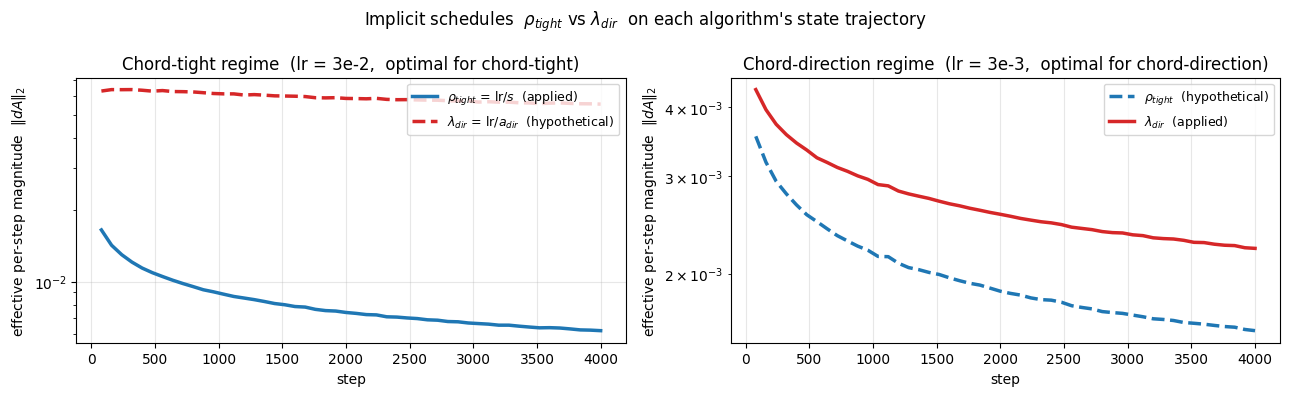


Gain = lambda_dir / rho_tight  (= s / a_dir) over training:
  at lr=3e-2 (chord-tight regime):     step 80 = 3.82, step 2000 = 7.89, step 4000 = 8.91
  at lr=3e-3 (chord-direction regime): step 80 = 1.21, step 2000 = 1.38, step 4000 = 1.41

At high lr the gap is huge — chord-direction would take 4-9x bigger steps than chord-tight at the same lr, which is too aggressive (chord-direction diverges at lr=3e-2).


In [ ]:
import json as _json

def _parse_log(path):
    rows = []
    with open(path) as f:
        for line in f:
            try: d = _json.loads(line)
            except Exception: continue
            if d.get('event') == 'optim_step' and 'lambda_dir_median' in d:
                rows.append(d)
    return rows

def _extract(rows):
    steps = np.array([r['step'] for r in rows])
    lam = np.array([r['lambda_dir_median'] for r in rows])
    gain = np.array([r['lambda_dir_gain_median'] for r in rows])
    rho = lam / gain
    return dict(step=steps, lam=lam, gain=gain, rho=rho)

CT_LOG = '/mnt/home/nghosh/lora/logs/chord_tight_r64_k3_snapshot_blackwell/run_info/logs/log_0.out'
CD_LOG = '/mnt/home/nghosh/lora/logs/chord_direction_4k_r16r64_blackwell/run_info/logs/log_0.out'

E_ct = _extract(_parse_log(CT_LOG))   # chord-tight applied @ lr=3e-2
E_cd = _extract(_parse_log(CD_LOG))   # chord-direction applied @ lr=3e-3

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: lr = 3e-2 (chord-tight applied, chord-direction shown as diagnostic)
ax = axes[0]
ax.plot(E_ct['step'], E_ct['rho'], color='C0', lw=2.5, label=r'$\rho_{tight}$ = lr$/s$  (applied)')
ax.plot(E_ct['step'], E_ct['lam'], color='C3', lw=2.5, ls='--', label=r'$\lambda_{dir}$ = lr$/a_{dir}$  (hypothetical)')
ax.set_yscale('log')
ax.set_xlabel('step'); ax.set_ylabel(r'effective per-step magnitude  $\|dA\|_2$')
ax.set_title('Chord-tight regime  (lr = 3e-2,  optimal for chord-tight)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=9, loc='upper right')

# Right: lr = 3e-3 (chord-direction applied, chord-tight shown as diagnostic)
ax = axes[1]
ax.plot(E_cd['step'], E_cd['rho'], color='C0', lw=2.5, ls='--', label=r'$\rho_{tight}$  (hypothetical)')
ax.plot(E_cd['step'], E_cd['lam'], color='C3', lw=2.5, label=r'$\lambda_{dir}$  (applied)')
ax.set_yscale('log')
ax.set_xlabel('step'); ax.set_ylabel(r'effective per-step magnitude  $\|dA\|_2$')
ax.set_title('Chord-direction regime  (lr = 3e-3,  optimal for chord-direction)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=9, loc='upper right')

fig.suptitle(r"Implicit schedules  $\rho_{tight}$ vs $\lambda_{dir}$  on each algorithm's state trajectory")
fig.tight_layout()
plt.show()

print(f'\nGain = lambda_dir / rho_tight  (= s / a_dir) over training:')
print(f'  at lr=3e-2 (chord-tight regime):     step 80 = {E_ct["gain"][np.argmin(np.abs(E_ct["step"]-80))]:.2f}, step 2000 = {E_ct["gain"][np.argmin(np.abs(E_ct["step"]-2000))]:.2f}, step 4000 = {E_ct["gain"][-1]:.2f}')
print(f'  at lr=3e-3 (chord-direction regime): step 80 = {E_cd["gain"][np.argmin(np.abs(E_cd["step"]-80))]:.2f}, step 2000 = {E_cd["gain"][np.argmin(np.abs(E_cd["step"]-2000))]:.2f}, step 4000 = {E_cd["gain"][-1]:.2f}')
print(f'\nAt high lr the gap is huge — chord-direction would take 4-9x bigger steps than chord-tight at the same lr, which is too aggressive (chord-direction diverges at lr=3e-2).')


## Higham (matrix inverse-sqrt) convergence

Chord-tight refreshes $S_A^{-1/2}, S_B^{-1/2}$ via the Iannazzo / Denman-Beavers coupled Newton-Schulz iteration (production: `n_iters=10`, cold-start each refresh). Quadratic convergence once eigenvalues of the scaled matrix are clustered near 1.

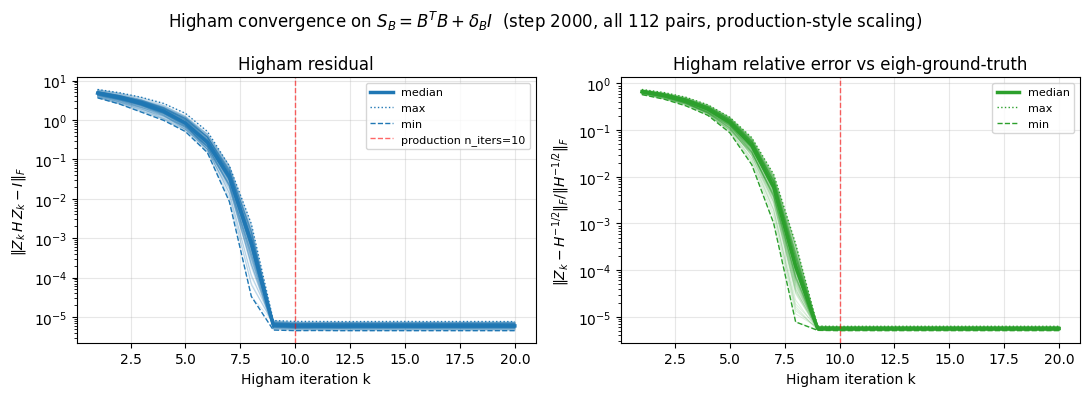


  k= 1:  residual median = 4.787e+00,  max = 5.931e+00
  k= 5:  residual median = 8.303e-01,  max = 1.468e+00
  k=10:  residual median = 5.953e-06,  max = 7.712e-06   <-- production n_iters=10
  k=15:  residual median = 5.946e-06,  max = 7.707e-06
  k=20:  residual median = 5.950e-06,  max = 7.646e-06


In [ ]:
import sys
if '/mnt/home/nghosh/lora' not in sys.path: sys.path.insert(0, '/mnt/home/nghosh/lora')
from lora_playground.spectral import lambda_max_power_iter_psd_batched

def higham_residual_traj(H, K_max=20, delta_abs=1e-6, device=DEV):
    # Production-style Higham: λ_max via lambda_max_power_iter_psd_batched (8 iters, 7 starts).
    # NOT eigh ground-truth — that would overstate Higham accuracy.
    H = H.to(device).float()
    H = 0.5 * (H + H.T)
    n = H.shape[-1]
    # absolute damping: δ = delta_abs (constant, independent of λ_max)
    lam_raw, _ = lambda_max_power_iter_psd_batched(H.unsqueeze(0), n_iters=8)
    eps_eff = delta_abs
    H_damped = H + eps_eff * torch.eye(n, device=device)
    # eigh ground truth for measuring error (NOT used in iteration)
    evals_d, U_d = torch.linalg.eigh(H_damped)
    Z_true = U_d @ torch.diag(evals_d.clamp_min(1e-30).rsqrt()) @ U_d.T
    # Production-style scaling: λ_max via multi-start power iter (8 iters)
    lam_max, _ = lambda_max_power_iter_psd_batched(H_damped.unsqueeze(0), n_iters=8)
    s = lam_max.item()
    eye = torch.eye(n, dtype=H.dtype, device=device)
    Y = H_damped / s; Z = eye.clone(); three_eye = 3.0 * eye
    residuals, diffs = [], []
    for k in range(1, K_max+1):
        T = three_eye - Z @ Y
        Y = 0.5 * (Y @ T); Z = 0.5 * (T @ Z)
        Z_phys = Z / (s ** 0.5)
        R = Z_phys @ H_damped @ Z_phys - eye
        residuals.append(R.norm().item())
        diffs.append((Z_phys - Z_true).norm().item() / Z_true.norm().item())
    return residuals, diffs

K_MAX = 20
snap = load_snapshot(2000)
higham_res, higham_diff = [], []
for pi, p in snap['pair_state'].items():
    B = p['B'].float().to(DEV)
    S_B = B.T @ B
    res, diff = higham_residual_traj(S_B, K_max=K_MAX)
    higham_res.append(res); higham_diff.append(diff)
higham_res = np.array(higham_res); higham_diff = np.array(higham_diff)
iters = np.arange(1, K_MAX+1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
for row in higham_res: ax.plot(iters, row, color='C0', alpha=0.15, lw=0.7)
ax.plot(iters, np.median(higham_res, axis=0), color='C0', lw=2.5, label='median')
ax.plot(iters, higham_res.max(axis=0), color='C0', lw=1, ls=':', label='max')
ax.plot(iters, higham_res.min(axis=0), color='C0', lw=1, ls='--', label='min')
ax.axvline(10, color='red', ls='--', alpha=0.6, lw=1, label='production n_iters=10')
ax.set_yscale('log'); ax.set_xlabel('Higham iteration k')
ax.set_ylabel(r'$\|Z_k\,H\,Z_k - I\|_F$')
ax.set_title('Higham residual')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

ax = axes[1]
for row in higham_diff: ax.plot(iters, row, color='C2', alpha=0.15, lw=0.7)
ax.plot(iters, np.median(higham_diff, axis=0), color='C2', lw=2.5, label='median')
ax.plot(iters, higham_diff.max(axis=0), color='C2', lw=1, ls=':', label='max')
ax.plot(iters, higham_diff.min(axis=0), color='C2', lw=1, ls='--', label='min')
ax.axvline(10, color='red', ls='--', alpha=0.6, lw=1)
ax.set_yscale('log'); ax.set_xlabel('Higham iteration k')
ax.set_ylabel(r'$\|Z_k - H^{-1/2}\|_F / \|H^{-1/2}\|_F$')
ax.set_title('Higham relative error vs eigh-ground-truth')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

fig.suptitle(r'Higham convergence on $S_B = B^T B + \delta_B I$  (step 2000, all 112 pairs, production-style scaling)')
fig.tight_layout(); plt.show()

print()
for k in [1, 5, 10, 15, 20]:
    tag = '   <-- production n_iters=10' if k == 10 else ''
    print(f'  k={k:2d}:  residual median = {np.median(higham_res[:, k-1]):.3e},  max = {higham_res[:, k-1].max():.3e}' + tag)

## Power iteration convergence for $\sigma_{\max}(A), \sigma_{\max}(B)$

Chord-tight needs $\sigma_{\max}(A), \sigma_{\max}(B)$ for $s = \sigma_{\max}(A) + \sigma_{\max}(B)$ → $\rho_{tight} = $ lr$/s$. Production: `n_iters=8`, warm-started across steps (`v_sigma_A`, `v_sigma_B` stashed in optimizer state).

**Left subplot: cold-start** — random init each call. This is the worst case. Shows what `n_iters=8` buys from scratch.

**Right subplot: warm-start** — simulate by computing the converged top eigenvector at step 1000, then using it as `v_init` for power iter on the same pair at step 2000. This is an UPPER BOUND on production warm-start error (production uses step t-1 as init; the (1000 → 2000) gap is 1000× larger than that). Production's actual error is smaller than what's shown here.

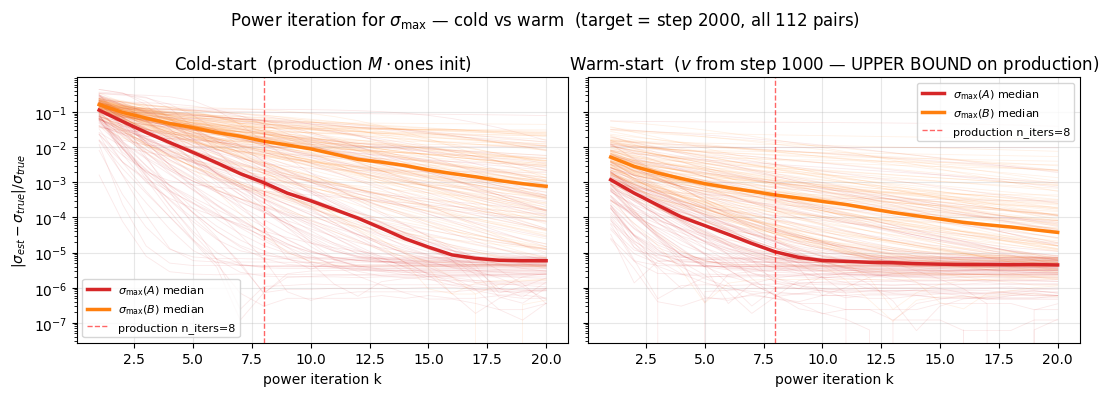


  k= 1  cold:  sA = 1.128e-01, sB = 1.625e-01  |  warm:  sA = 1.182e-03, sB = 5.205e-03
  k= 4  cold:  sA = 1.351e-02, sB = 4.704e-02  |  warm:  sA = 1.035e-04, sB = 1.279e-03
  k= 8  cold:  sA = 9.754e-04, sB = 1.474e-02  |  warm:  sA = 1.048e-05, sB = 4.357e-04   <-- production n_iters=8
  k=12  cold:  sA = 9.562e-05, sB = 4.493e-03  |  warm:  sA = 5.295e-06, sB = 1.792e-04
  k=20  cold:  sA = 5.875e-06, sB = 7.696e-04  |  warm:  sA = 4.458e-06, sB = 3.753e-05


In [ ]:
import sys
if '/mnt/home/nghosh/lora' not in sys.path: sys.path.insert(0, '/mnt/home/nghosh/lora')

def power_iter_traj(M, K_max=20, v_init=None, device=DEV):
    # Production-style cold-start: M @ ones init (deterministic).
    M = M.to(device).float()
    sigma_true = torch.linalg.svdvals(M)[0].item()
    mm, nn = M.shape
    smaller_m = mm <= nn
    if v_init is None:
        # Production fallback: M @ ones (smaller_m) or M^T @ ones
        if smaller_m:
            v = (M @ torch.ones(nn, device=device, dtype=M.dtype))
        else:
            v = (M.T @ torch.ones(mm, device=device, dtype=M.dtype))
    else:
        v = v_init.to(device).float()
    v = v / (v.norm() + 1e-30)
    errs = []
    # Match production: iterate on smaller-side Gram
    if smaller_m:
        # v lives in R^m, iterate v <- M^T M ... no wait, v should be in left singular space here
        # Production code does smaller_m branch with v in R^m (left singular space)
        for k in range(1, K_max+1):
            tmp = M.T @ v
            v = M @ tmp
            v_norm = v.norm()
            v = v / (v_norm + 1e-30)
            # sigma = ||M^T v|| (Rayleigh-like)
            sigma_est = (M.T @ v).norm().item()
            errs.append(abs(sigma_est - sigma_true) / max(sigma_true, 1e-30))
    else:
        # v lives in R^n (right singular space)
        for k in range(1, K_max+1):
            tmp = M @ v
            v = M.T @ tmp
            v_norm = v.norm()
            v = v / (v_norm + 1e-30)
            sigma_est = (M @ v).norm().item()
            errs.append(abs(sigma_est - sigma_true) / max(sigma_true, 1e-30))
    return errs, v

def converged_v(M, K=100, device=DEV):
    _, v = power_iter_traj(M, K_max=K, v_init=None, device=device)
    return v.detach()

K_MAX = 20
snap_warm_src = load_snapshot(1000)
snap_warm_dst = load_snapshot(2000)

# Cold-start at step 2000 (production-style: M @ ones init)
cold_A, cold_B = [], []
for pi, p in snap_warm_dst['pair_state'].items():
    A = p['A'].float().to(DEV); B = p['B'].float().to(DEV)
    e, _ = power_iter_traj(A, K_max=K_MAX, v_init=None); cold_A.append(e)
    e, _ = power_iter_traj(B, K_max=K_MAX, v_init=None); cold_B.append(e)

# Warm-start at step 2000 using v converged at step 1000
warm_A, warm_B = [], []
for pi, p_dst in snap_warm_dst['pair_state'].items():
    p_src = snap_warm_src['pair_state'][pi]
    A_src = p_src['A'].float().to(DEV); B_src = p_src['B'].float().to(DEV)
    v_A_src = converged_v(A_src)
    v_B_src = converged_v(B_src)
    A_dst = p_dst['A'].float().to(DEV); B_dst = p_dst['B'].float().to(DEV)
    e, _ = power_iter_traj(A_dst, K_max=K_MAX, v_init=v_A_src); warm_A.append(e)
    e, _ = power_iter_traj(B_dst, K_max=K_MAX, v_init=v_B_src); warm_B.append(e)

cold_A = np.array(cold_A); cold_B = np.array(cold_B)
warm_A = np.array(warm_A); warm_B = np.array(warm_B)
iters = np.arange(1, K_MAX+1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ax = axes[0]
for row in cold_A: ax.plot(iters, row, color='C3', alpha=0.10, lw=0.6)
for row in cold_B: ax.plot(iters, row, color='C1', alpha=0.10, lw=0.6)
ax.plot(iters, np.median(cold_A, axis=0), color='C3', lw=2.5, label=r'$\sigma_{\max}(A)$ median')
ax.plot(iters, np.median(cold_B, axis=0), color='C1', lw=2.5, label=r'$\sigma_{\max}(B)$ median')
ax.axvline(8, color='red', ls='--', alpha=0.6, lw=1, label='production n_iters=8')
ax.set_yscale('log'); ax.set_xlabel('power iteration k')
ax.set_ylabel(r'$|\sigma_{est} - \sigma_{true}| / \sigma_{true}$')
ax.set_title('Cold-start  (production $M\\cdot$ones init)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

ax = axes[1]
for row in warm_A: ax.plot(iters, row, color='C3', alpha=0.10, lw=0.6)
for row in warm_B: ax.plot(iters, row, color='C1', alpha=0.10, lw=0.6)
ax.plot(iters, np.median(warm_A, axis=0), color='C3', lw=2.5, label=r'$\sigma_{\max}(A)$ median')
ax.plot(iters, np.median(warm_B, axis=0), color='C1', lw=2.5, label=r'$\sigma_{\max}(B)$ median')
ax.axvline(8, color='red', ls='--', alpha=0.6, lw=1, label='production n_iters=8')
ax.set_xlabel('power iteration k')
ax.set_title('Warm-start  ($v$ from step 1000 — UPPER BOUND on production)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

fig.suptitle(r'Power iteration for $\sigma_{\max}$ — cold vs warm  (target = step 2000, all 112 pairs)')
fig.tight_layout(); plt.show()

print()
for k in [1, 4, 8, 12, 20]:
    tag = '   <-- production n_iters=8' if k == 8 else ''
    print(f'  k={k:2d}  cold:  sA = {np.median(cold_A[:, k-1]):.3e}, sB = {np.median(cold_B[:, k-1]):.3e}  |  warm:  sA = {np.median(warm_A[:, k-1]):.3e}, sB = {np.median(warm_B[:, k-1]):.3e}' + tag)

## Lemma 4 + Lemma 5: $R^{(n)}$ in Algorithms 2 and 2′

§10 of `algorithm_tight_chord.md` defines the polar-input ratio

$$R^{(n)} := \frac{(\gamma/\beta)\,\|C_A^{(n)}\|_2}{\sigma_{\max}(X_A)}$$

— the cross-coupling magnitude relative to the base term inside the polar
argument. When $R \ll 1$, polar ignores the cross-coupling and Picard is inert.
When $R = \Theta(1)$, the cross-coupling enters the polar output.

- **Algorithm 2:** $R_2^{(n)} = \|C_A^{(n)}\|_2 / (\eta\,\sigma_{\max}(X_A))$. Lemma 4 upper bound: $(\sigma_{\min}(B) + \sqrt{\delta_{\rm abs}})/\alpha$.
- **Algorithm 2′:** $R_{2'}^{(n)} = 2\|C_A^{(n)}\|_2 / (\rho s)$. Lemma 5 upper bound: $2\sigma_{\max}(A)/s \le 2$.

Both are measured at $n=2$ (smallest $n$ with $C_A^{(n)} \ne 0$).


In [ ]:
ETA = 3e-2
DELTA_ABS = 1e-6

def lemma_measurement(p, eta=ETA, delta_abs=DELTA_ABS, ns_iters=5):
    A = p['A'].float().to(DEV); B = p['B'].float().to(DEV)
    u_A = p['u_A'].float().to(DEV); u_B = p['u_B'].float().to(DEV)
    r = A.shape[0]; I_r = torch.eye(r, dtype=A.dtype, device=DEV)

    S_B = B.T @ B
    eB_raw, V_B = torch.linalg.eigh(S_B)
    eB_raw = eB_raw.clamp_min(0)
    sigma_min_B = eB_raw[0].sqrt().item()
    sigma_max_B = eB_raw[-1].sqrt().item()
    w = V_B[:, 0]

    delta_B = delta_abs
    e2B, UB = torch.linalg.eigh(S_B + delta_B * I_r)
    W_B = UB @ torch.diag(e2B.clamp_min(1e-30).rsqrt()) @ UB.T

    X_A = W_B @ u_A
    sigma_max_X_A = torch.linalg.eigvalsh(X_A @ X_A.T).clamp_min(0).max().sqrt().item()
    alpha = (w @ u_A).norm().item()

    S_A = A @ A.T
    eA_raw = torch.linalg.eigvalsh(S_A).clamp_min(0)
    delta_A = delta_abs
    e2A, UA = torch.linalg.eigh(S_A + delta_A * I_r)
    W_A = UA @ torch.diag(e2A.clamp_min(1e-30).rsqrt()) @ UA.T
    sigma_max_A = eA_raw.max().sqrt().item()
    s_AB = sigma_max_A + sigma_max_B
    rho = eta / s_AB  # linear-regime form, matches simulate_bcd

    # BJ iter 1 (no cross-coupling) → dB^(1) for both algorithms.
    # At iter 1, polar input differs: Alg 2 uses X_A, Alg 2' uses X_A/sigma_max(X_A).
    # But polar is scale-invariant, so polar output is the same → dB^(1) identical.
    D_A = W_B @ newton_schulz_polar(W_B @ u_A, ns_iters)
    D_B = newton_schulz_polar(u_B @ W_A, ns_iters) @ W_A
    D_A_op = torch.linalg.eigvalsh(D_A @ D_A.T).clamp_min(0).max().sqrt().item()
    D_B_op = torch.linalg.eigvalsh(D_B.T @ D_B).clamp_min(0).max().sqrt().item()
    dB1 = -rho * D_B / D_B_op

    # C_A^(2) and its operator norm.
    C_A2 = W_B @ B.T @ dB1 @ A
    norm_C_A2 = torch.linalg.eigvalsh(C_A2 @ C_A2.T).clamp_min(0).max().sqrt().item()

    # R for both algorithms.
    R2_actual  = (norm_C_A2 / eta) / max(sigma_max_X_A, 1e-30)
    R2p_actual = (2.0 * norm_C_A2) / (rho * s_AB)

    # Bounds.
    R2_bound  = (sigma_min_B + delta_abs ** 0.5) / max(alpha, 1e-30)
    R2p_bound = 2.0 * sigma_max_A / s_AB

    return dict(R2_actual=R2_actual, R2_bound=R2_bound,
                R2p_actual=R2p_actual, R2p_bound=R2p_bound,
                sigma_min_B=sigma_min_B, sigma_max_B=sigma_max_B,
                sigma_max_A=sigma_max_A, sigma_max_X_A=sigma_max_X_A,
                alpha=alpha,
                kappa_B=sigma_max_B / max(sigma_min_B, 1e-30),
                sA_over_s=sigma_max_A / s_AB)

lemma_rows = []
for step in STEPS:
    if step == 0:
        continue
    snap = load_snapshot(step)
    for pi, p in snap['pair_state'].items():
        r = lemma_measurement(p)
        r['step'] = step; r['pair'] = pi
        lemma_rows.append(r)

print(f'computed Lemma 4 + Lemma 5 on {len(lemma_rows)} (step, pair) cells')
print(f'Lemma 4 holds (R2_bound > R2_actual):   {sum(r["R2_bound"]  > r["R2_actual"]  for r in lemma_rows) / len(lemma_rows):.1%}')
print(f'Lemma 5 holds (R2p_bound > R2p_actual): {sum(r["R2p_bound"] > r["R2p_actual"] for r in lemma_rows) / len(lemma_rows):.1%}')


computed Lemma 4 + Lemma 5 on 672 (step, pair) cells
Lemma 4 holds (R2_bound > R2_actual):   100.0%
Lemma 5 holds (R2p_bound > R2p_actual): 100.0%


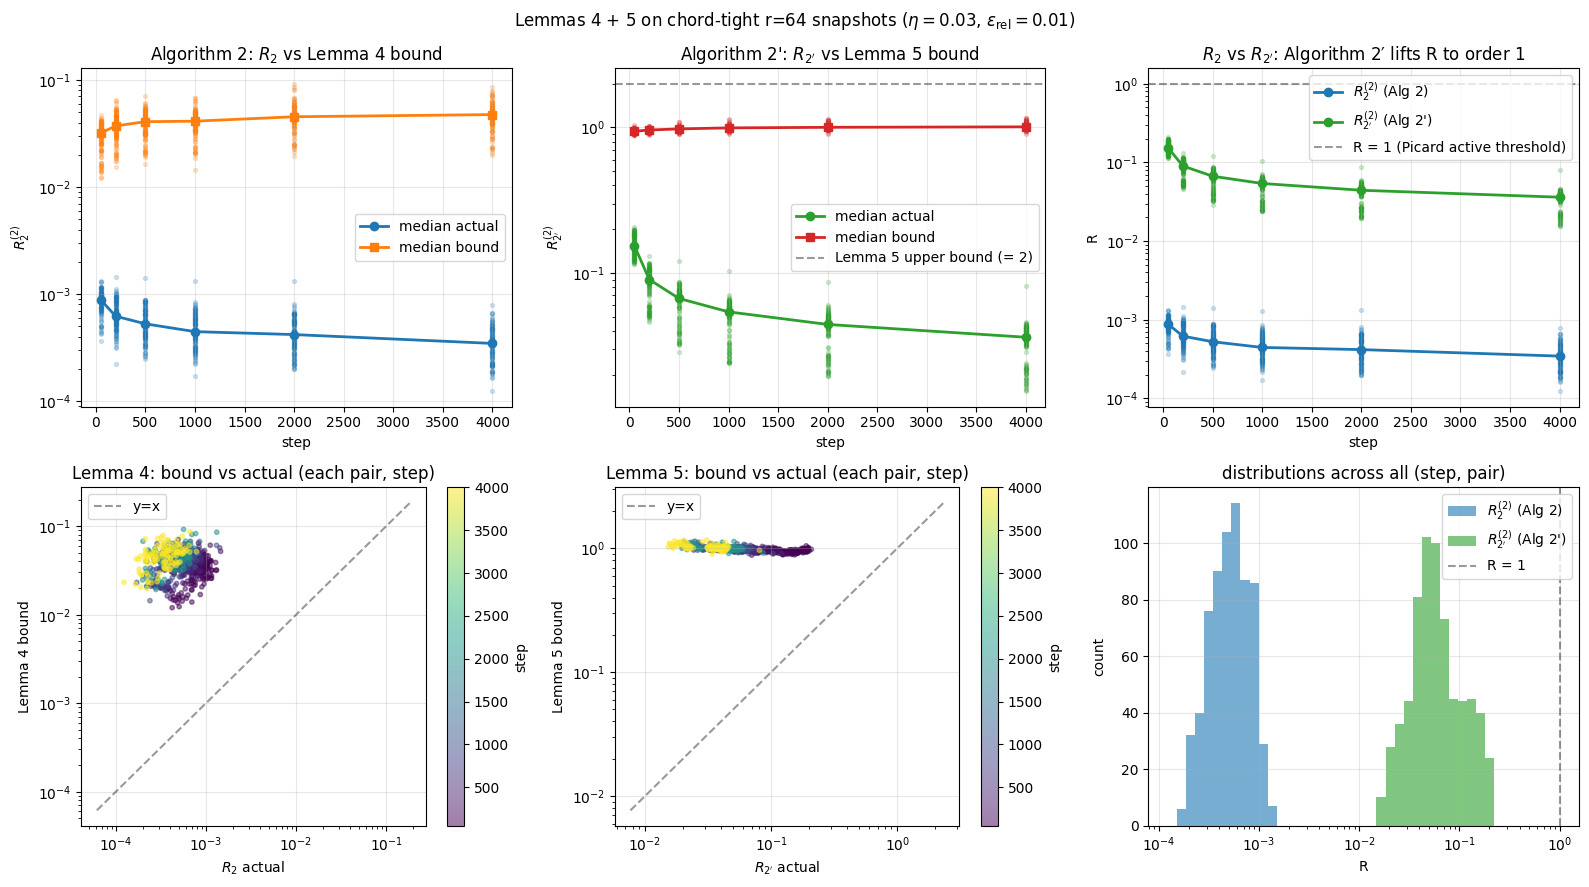

=== $R_2^{(2)}$ actual (Algorithm 2) ===
  median: 5.217e-04, max: 1.454e-03
  frac < 0.1: 100.0%, frac < 1: 100.0%

=== $R_{2'}^{(2)}$ actual (Algorithm 2') ===
  median: 5.594e-02, max: 2.085e-01
  frac >= 0.1: 22.3%, frac in [0.1, 2]: 22.3%

=== ratio R_{2'} / R_2 (lifting factor) ===
  median: 106.3x, max: 477.6x
  predicted ≈ 2·σ_max(X_A); median 2·σ_max(X_A) = 106.3

=== Bounds ===
  Lemma 4 bound:  median 4.024e-02, max 9.213e-02, holds 100.0%
  Lemma 5 bound:  median 9.818e-01, max 1.167e+00, holds 100.0%


In [ ]:
import pandas as pd
df = pd.DataFrame(lemma_rows)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
steps_sorted = sorted(df['step'].unique())

# Panel (0,0): R_2 actual vs bound over training.
ax = axes[0, 0]
for step in steps_sorted:
    sub = df[df['step'] == step]
    ax.scatter([step]*len(sub), sub['R2_actual'], color='C0', alpha=0.2, s=8)
    ax.scatter([step]*len(sub), sub['R2_bound'],  color='C1', alpha=0.2, s=8)
ax.plot(steps_sorted, df.groupby('step')['R2_actual'].median().loc[steps_sorted], 'C0o-', lw=2, label='median actual')
ax.plot(steps_sorted, df.groupby('step')['R2_bound'].median().loc[steps_sorted],  'C1s-', lw=2, label='median bound')
ax.set_yscale('log'); ax.set_xlabel('step'); ax.set_ylabel('$R_2^{(2)}$')
ax.set_title('Algorithm 2: $R_2$ vs Lemma 4 bound'); ax.legend(); ax.grid(True, alpha=0.3)

# Panel (0,1): R_{2'} actual vs bound over training.
ax = axes[0, 1]
for step in steps_sorted:
    sub = df[df['step'] == step]
    ax.scatter([step]*len(sub), sub['R2p_actual'], color='C2', alpha=0.2, s=8)
    ax.scatter([step]*len(sub), sub['R2p_bound'],  color='C3', alpha=0.2, s=8)
ax.plot(steps_sorted, df.groupby('step')['R2p_actual'].median().loc[steps_sorted], 'C2o-', lw=2, label='median actual')
ax.plot(steps_sorted, df.groupby('step')['R2p_bound'].median().loc[steps_sorted],  'C3s-', lw=2, label='median bound')
ax.axhline(2.0, color='k', ls='--', alpha=0.4, label='Lemma 5 upper bound (= 2)')
ax.set_yscale('log'); ax.set_xlabel('step'); ax.set_ylabel("$R_{2'}^{(2)}$")
ax.set_title("Algorithm 2': $R_{2'}$ vs Lemma 5 bound"); ax.legend(); ax.grid(True, alpha=0.3)

# Panel (0,2): R_2 vs R_{2'} on the same axes — the key comparison.
ax = axes[0, 2]
for step in steps_sorted:
    sub = df[df['step'] == step]
    ax.scatter([step]*len(sub), sub['R2_actual'],  color='C0', alpha=0.2, s=8)
    ax.scatter([step]*len(sub), sub['R2p_actual'], color='C2', alpha=0.2, s=8)
ax.plot(steps_sorted, df.groupby('step')['R2_actual'].median().loc[steps_sorted],  'C0o-', lw=2, label='$R_2^{(2)}$ (Alg 2)')
ax.plot(steps_sorted, df.groupby('step')['R2p_actual'].median().loc[steps_sorted], 'C2o-', lw=2, label="$R_{2'}^{(2)}$ (Alg 2')")
ax.axhline(1.0, color='k', ls='--', alpha=0.4, label='R = 1 (Picard active threshold)')
ax.set_yscale('log'); ax.set_xlabel('step'); ax.set_ylabel('R')
ax.set_title("$R_2$ vs $R_{2'}$: Algorithm 2′ lifts R to order 1"); ax.legend(); ax.grid(True, alpha=0.3)

# Panel (1,0): scatter R_2 bound vs actual.
ax = axes[1, 0]
sc = ax.scatter(df['R2_actual'], df['R2_bound'], c=df['step'], cmap='viridis', alpha=0.5, s=10)
lim_lo = min(df['R2_actual'].min(), df['R2_bound'].min()) * 0.5
lim_hi = max(df['R2_actual'].max(), df['R2_bound'].max()) * 2
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', alpha=0.4, label='y=x')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('$R_2$ actual'); ax.set_ylabel('Lemma 4 bound')
ax.set_title('Lemma 4: bound vs actual (each pair, step)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='step')

# Panel (1,1): scatter R_{2'} bound vs actual.
ax = axes[1, 1]
sc = ax.scatter(df['R2p_actual'], df['R2p_bound'], c=df['step'], cmap='viridis', alpha=0.5, s=10)
lim_lo = min(df['R2p_actual'].min(), df['R2p_bound'].min()) * 0.5
lim_hi = max(df['R2p_actual'].max(), df['R2p_bound'].max()) * 2
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', alpha=0.4, label='y=x')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel("$R_{2'}$ actual"); ax.set_ylabel('Lemma 5 bound')
ax.set_title("Lemma 5: bound vs actual (each pair, step)"); ax.legend(); ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='step')

# Panel (1,2): histograms of R_2 vs R_{2'} across all pairs/steps.
ax = axes[1, 2]
bins = np.logspace(np.log10(max(df['R2_actual'].min(), 1e-10)),
                   np.log10(df['R2p_actual'].max() * 2), 40)
ax.hist(df['R2_actual'].clip(lower=1e-10),  bins=bins, alpha=0.6, color='C0', label='$R_2^{(2)}$ (Alg 2)')
ax.hist(df['R2p_actual'].clip(lower=1e-10), bins=bins, alpha=0.6, color='C2', label="$R_{2'}^{(2)}$ (Alg 2')")
ax.axvline(1.0, color='k', ls='--', alpha=0.4, label='R = 1')
ax.set_xscale('log'); ax.set_xlabel('R'); ax.set_ylabel('count')
ax.set_title('distributions across all (step, pair)'); ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle(rf'Lemmas 4 + 5 on chord-tight r=64 snapshots ($\eta=${ETA}, $\delta_{{\rm abs}}=${DELTA_ABS})')
fig.tight_layout()
plt.show()

print('=== $R_2^{(2)}$ actual (Algorithm 2) ===')
print(f"  median: {df['R2_actual'].median():.3e}, max: {df['R2_actual'].max():.3e}")
print(f"  frac < 0.1: {(df['R2_actual'] < 0.1).mean():.1%}, frac < 1: {(df['R2_actual'] < 1).mean():.1%}")
print()
print("=== $R_{2'}^{(2)}$ actual (Algorithm 2') ===")
print(f"  median: {df['R2p_actual'].median():.3e}, max: {df['R2p_actual'].max():.3e}")
print(f"  frac >= 0.1: {(df['R2p_actual'] >= 0.1).mean():.1%}, frac in [0.1, 2]: {((df['R2p_actual'] >= 0.1) & (df['R2p_actual'] <= 2)).mean():.1%}")
print()
print('=== ratio R_{2\'} / R_2 (lifting factor) ===')
ratio = df['R2p_actual'] / df['R2_actual'].clip(lower=1e-30)
print(f"  median: {ratio.median():.1f}x, max: {ratio.max():.1f}x")
print(f"  predicted ≈ 2·σ_max(X_A); median 2·σ_max(X_A) = {(2 * df['sigma_max_X_A']).median():.1f}")
print()
print('=== Bounds ===')
print(f"  Lemma 4 bound:  median {df['R2_bound'].median():.3e}, max {df['R2_bound'].max():.3e}, holds {(df['R2_bound']  > df['R2_actual']).mean():.1%}")
print(f"  Lemma 5 bound:  median {df['R2p_bound'].median():.3e}, max {df['R2p_bound'].max():.3e}, holds {(df['R2p_bound'] > df['R2p_actual']).mean():.1%}")
